# Ensemble Learning Framework for network intrusion detection system using machine learning

**Project Overview:**
- Baseline Decision Tree classifier
- Ensemble methods: Bagging, AdaBoost, RUSBoost
- Feature selection using mRMR
- K-fold cross-validation
- Comprehensive evaluation metrics


## 1. Install Required Packages


In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn mrmr-selection xgboost tensorflow keras kagglehub pyarrow -q


## 2. Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error
)
from imblearn.ensemble import RUSBoostClassifier
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Storytelling visual style (applies to all charts)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.size'] = 10

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    print("Warning: XGBoost not installed.")
    XGBOOST_AVAILABLE = False

# Autoencoder (TensorFlow/Keras)
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, models
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TENSORFLOW_AVAILABLE = True
except ImportError:
    print("Warning: TensorFlow not installed. Autoencoder will not be available.")
    TENSORFLOW_AVAILABLE = False

# For mRMR feature selection
try:
    from mrmr import mrmr_classif
    MRMR_AVAILABLE = True
except ImportError:
    print("Warning: mrmr-selection not installed. Using alternative feature selection.")
    MRMR_AVAILABLE = False
    from sklearn.feature_selection import SelectKBest, f_classif

# Configuration
RANDOM_STATE = 42
N_FOLDS = 10
TEST_SIZE = 0.2
VALIDATION_SIZE = 0.2


## 3. Upload CSV Data


In [ ]:
# ============================================================================
# DATA LOADING - KaggleHub dataset
# ============================================================================

import os
import kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("ziya07/network-traffic-anomaly-detection-dataset")

print("Path to dataset files:", path)

# Find CSV files in downloaded folder
csv_files = [f for f in os.listdir(path) if f.lower().endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV files found in downloaded Kaggle dataset folder.")

# Load first CSV by default (change index if needed)
selected_csv = csv_files[0]
file_path = os.path.join(path, selected_csv)
print(f"Loading data from: {file_path}")
df = pd.read_csv(file_path)
print("✓ File loaded successfully")

# Display basic information
print(f"\nData shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

# Display data types
print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"\nData Types:")
print(df.dtypes)

print(f"\nMissing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values")

print(f"\nFirst few rows:")
df.head()

# Display column statistics
print("\n" + "="*60)
print("COLUMN STATISTICS")
print("="*60)
print(df.describe())


Using Colab cache for faster access to the 'network-traffic-anomaly-detection-dataset' dataset.
Path to dataset files: /kaggle/input/network-traffic-anomaly-detection-dataset
Loading data from: /kaggle/input/network-traffic-anomaly-detection-dataset/embedded_system_network_security_dataset.csv
✓ File loaded successfully

Data shape: 1000 rows × 18 columns
Columns: ['packet_size', 'inter_arrival_time', 'src_port', 'dst_port', 'packet_count_5s', 'mean_packet_size', 'spectral_entropy', 'frequency_band_energy', 'label', 'protocol_type_TCP', 'protocol_type_UDP', 'src_ip_192.168.1.2', 'src_ip_192.168.1.3', 'dst_ip_192.168.1.5', 'dst_ip_192.168.1.6', 'tcp_flags_FIN', 'tcp_flags_SYN', 'tcp_flags_SYN-ACK']

DATASET INFORMATION

Data Types:
packet_size              float64
inter_arrival_time       float64
src_port                   int64
dst_port                   int64
packet_count_5s          float64
mean_packet_size         float64
spectral_entropy         float64
frequency_band_energy    flo

## 4. Protocol Feature Engineering (FTP, HTTP, NTP, and Other Protocols)

This section adds protocol-specific features and scores that will be used by all models:
- **FTP Score**: Based on FTP ports (20/21) and bidirectional traffic
- **HTTP Score**: Based on HTTP port (80) and byte count
- **HTTPS Score**: Based on HTTPS port (443) and encrypted traffic
- **NTP Score**: Based on NTP port (123) and time sync patterns
- **Other Protocol Scores**: SSH, DNS, ICMP, TCP, UDP, SMTP, TELNET, etc.
- **Protocol Risk Score**: Higher for less common protocols
- **Protocol Indicators**: Binary features for each protocol type

These features are automatically included in model training and evaluation.


In [ ]:
# =============================================================================
# PROTOCOL FEATURE ENGINEERING (Compatible with your dataset)
# =============================================================================

import pandas as pd
import numpy as np

PROTOCOL_PORTS = {
    'FTP': [20, 21],
    'HTTP': [80, 8080],
    'HTTPS': [443],
    'SSH': [22],
    'TELNET': [23],
    'SMTP': [25, 587],
    'DNS': [53],
    'DHCP': [67, 68],
    'SNMP': [161, 162],
    'LDAP': [389],
    'RDP': [3389],
    'MYSQL': [3306],
    'POSTGRESQL': [5432],
    'MONGODB': [27017],
    'REDIS': [6379],
    'NTP': [123],
    'SIP': [5060],
    'RTSP': [554],
    'VNC': [5900]
}


def detect_protocol(src_port, dst_port, tcp, udp):

    ports = [int(src_port), int(dst_port)]

    for proto, plist in PROTOCOL_PORTS.items():
        for p in ports:
            if p in plist:
                return proto

    if tcp == 1:
        return "TCP"

    if udp == 1:
        return "UDP"

    return "UNKNOWN"


def create_protocol_features(df):

    df = df.copy()

    print("="*60)
    print("Protocol Feature Engineering")
    print("="*60)

    ####################################################
    # Detect Application Protocol
    ####################################################

    df["detected_protocol"] = df.apply(
        lambda x: detect_protocol(
            x["src_port"],
            x["dst_port"],
            x["protocol_type_TCP"],
            x["protocol_type_UDP"]
        ),
        axis=1
    )

    ####################################################
    # Binary Protocol Features
    ####################################################

    protocol_list = [
        'FTP','HTTP','HTTPS','SSH','TELNET',
        'SMTP','DNS','DHCP','SNMP','LDAP',
        'RDP','MYSQL','POSTGRESQL','MONGODB',
        'REDIS','NTP','SIP','RTSP','VNC',
        'TCP','UDP'
    ]

    for p in protocol_list:
        df[f'is_{p.lower()}'] = (df["detected_protocol"]==p).astype(int)

    ####################################################
    # Feature Scores
    ####################################################

    # HTTP Score
    df["http_score"] = (
        df["is_http"] *
        (df["packet_size"]/df["packet_size"].max())
    )

    # HTTPS Score
    df["https_score"] = (
        df["is_https"] *
        (df["packet_size"]/df["packet_size"].max())
    )

    # FTP Score
    df["ftp_score"] = (
        df["is_ftp"] *
        (df["packet_count_5s"]/df["packet_count_5s"].max())
    )

    # DNS Score
    df["dns_score"] = (
        df["is_dns"] *
        (1/(df["packet_size"]+1))
    )

    # SSH Score
    df["ssh_score"] = (
        df["is_ssh"] *
        (1/(df["inter_arrival_time"]+1))
    )

    # TCP Score
    df["tcp_score"] = (
        df["protocol_type_TCP"] *
        (df["packet_count_5s"]/df["packet_count_5s"].max())
    )

    # UDP Score
    df["udp_score"] = (
        df["protocol_type_UDP"] *
        (df["packet_count_5s"]/df["packet_count_5s"].max())
    )

    ####################################################
    # TCP Flag Features
    ####################################################

    df["connection_start"] = df["tcp_flags_SYN"]

    df["connection_end"] = df["tcp_flags_FIN"]

    df["handshake"] = df["tcp_flags_SYN-ACK"]

    ####################################################
    # Entropy Features
    ####################################################

    df["traffic_complexity"] = (
        df["spectral_entropy"] *
        df["frequency_band_energy"]
    )

    ####################################################
    # Packet Features
    ####################################################

    df["packet_rate"] = (
        df["packet_count_5s"] /
        (df["inter_arrival_time"] + 1)
    )

    df["size_ratio"] = (
        df["packet_size"] /
        (df["mean_packet_size"] + 1)
    )

    ####################################################
    # Protocol Risk Score
    ####################################################

    counts = df["detected_protocol"].value_counts()

    total = len(df)

    risk = {}

    for p,c in counts.items():
        risk[p] = 1/(c/total)

    df["protocol_risk_score"] = df["detected_protocol"].map(risk)

    ####################################################
    # Diversity
    ####################################################

    protocol_cols = [c for c in df.columns if c.startswith("is_")]

    df["protocol_diversity"] = df[protocol_cols].sum(axis=1)

    ####################################################
    # Summary
    ####################################################

    print("\nNew Features Added:")

    new_cols = [c for c in df.columns if c not in [
        'packet_size',
        'inter_arrival_time',
        'src_port',
        'dst_port',
        'packet_count_5s',
        'mean_packet_size',
        'spectral_entropy',
        'frequency_band_energy',
        'label',
        'protocol_type_TCP',
        'protocol_type_UDP',
        'src_ip_192.168.1.2',
        'src_ip_192.168.1.3',
        'dst_ip_192.168.1.5',
        'dst_ip_192.168.1.6',
        'tcp_flags_FIN',
        'tcp_flags_SYN',
        'tcp_flags_SYN-ACK'
    ]]

    print(new_cols)

    print("\nProtocol Distribution")

    print(df["detected_protocol"].value_counts())

    return df


# Apply Feature Engineering
df = create_protocol_features(df)

print("\nDataset Shape:", df.shape)
print("\nFirst 5 rows")
print(df.head())

Protocol Feature Engineering

New Features Added:
['detected_protocol', 'is_ftp', 'is_http', 'is_https', 'is_ssh', 'is_telnet', 'is_smtp', 'is_dns', 'is_dhcp', 'is_snmp', 'is_ldap', 'is_rdp', 'is_mysql', 'is_postgresql', 'is_mongodb', 'is_redis', 'is_ntp', 'is_sip', 'is_rtsp', 'is_vnc', 'is_tcp', 'is_udp', 'http_score', 'https_score', 'ftp_score', 'dns_score', 'ssh_score', 'tcp_score', 'udp_score', 'connection_start', 'connection_end', 'handshake', 'traffic_complexity', 'packet_rate', 'size_ratio', 'protocol_risk_score', 'protocol_diversity']

Protocol Distribution
detected_protocol
HTTPS    353
HTTP     337
DNS      310
Name: count, dtype: int64

Dataset Shape: (1000, 55)

First 5 rows
   packet_size  inter_arrival_time  src_port  dst_port  packet_count_5s  \
0       0.4052              0.6204     62569       443           0.8571   
1       0.5276              0.7413     59382       443           0.7857   
2       0.2262              0.4851     65484        80           0.2857   
3   

### Protocol Features Visualization

Visualize the protocol distribution and scores that will be used by all models.


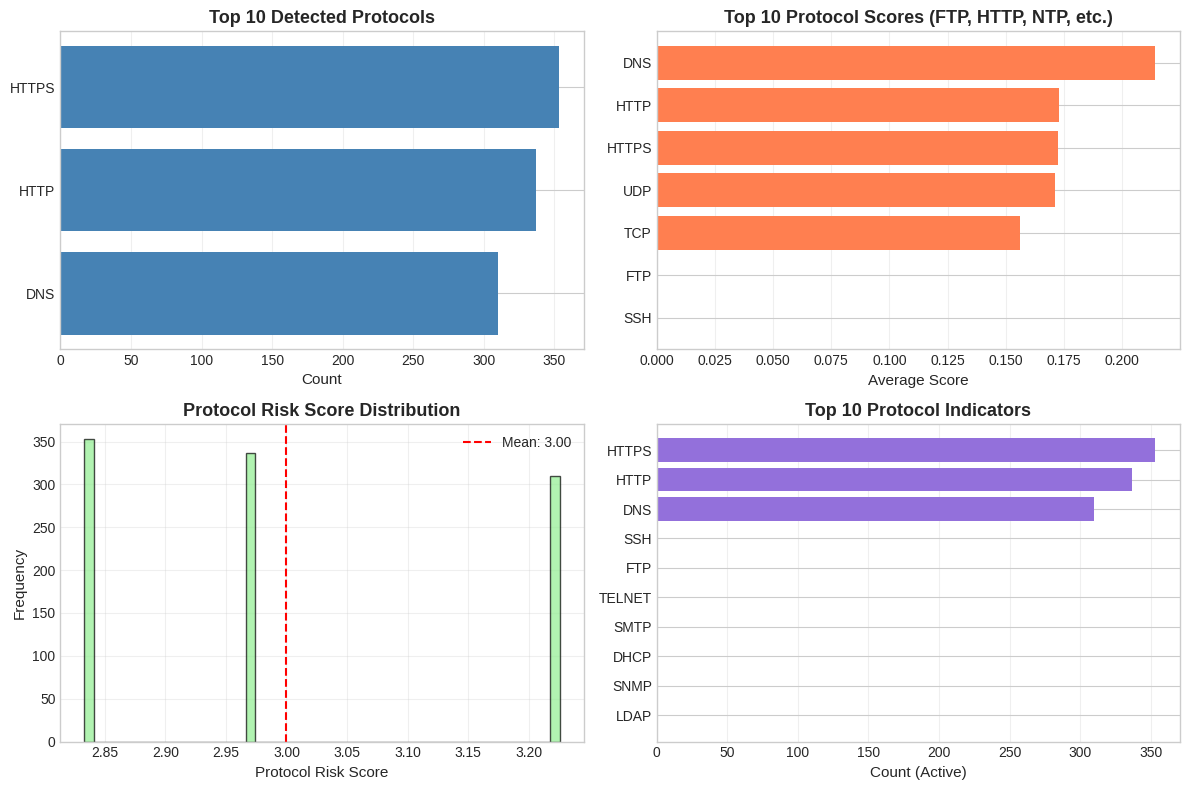


PROTOCOL FEATURES SUMMARY STATISTICS

Protocol Scores (Mean) - Used by All Models:
  dns_score           : Mean=0.2141, Max=0.9922, Active=310
  ftp_score           : Mean=0.0000, Max=0.0000, Active=0
  http_score          : Mean=0.1730, Max=1.0000, Active=335
  https_score         : Mean=0.1725, Max=0.9993, Active=353
  ssh_score           : Mean=0.0000, Max=0.0000, Active=0
  tcp_score           : Mean=0.1561, Max=1.0000, Active=295
  udp_score           : Mean=0.1710, Max=1.0000, Active=329

Protocol Indicators (Total Active) - Used by All Models:
  is_dhcp             :      0 ( 0.00%)
  is_dns              :    310 (31.00%)
  is_ftp              :      0 ( 0.00%)
  is_http             :    337 (33.70%)
  is_https            :    353 (35.30%)
  is_ldap             :      0 ( 0.00%)
  is_mongodb          :      0 ( 0.00%)
  is_mysql            :      0 ( 0.00%)
  is_ntp              :      0 ( 0.00%)
  is_postgresql       :      0 ( 0.00%)
  is_rdp              :      0 ( 0.00%)
  

In [ ]:
# Visualize protocol distribution and scores
if 'detected_protocol' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Protocol distribution
    proto_counts = df['detected_protocol'].value_counts().head(10)
    axes[0, 0].barh(range(len(proto_counts)), proto_counts.values, color='steelblue')
    axes[0, 0].set_yticks(range(len(proto_counts)))
    axes[0, 0].set_yticklabels(proto_counts.index)
    axes[0, 0].set_xlabel('Count')
    axes[0, 0].set_title('Top 10 Detected Protocols', fontweight='bold')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)

    # Protocol scores distribution (FTP, HTTP, NTP, etc.)
    score_cols = [col for col in df.columns if col.endswith('_score') and col != 'protocol_risk_score']
    if score_cols:
        score_data = df[score_cols].mean().sort_values(ascending=False).head(10)
        axes[0, 1].barh(range(len(score_data)), score_data.values, color='coral')
        axes[0, 1].set_yticks(range(len(score_data)))
        axes[0, 1].set_yticklabels([col.replace('_score', '').upper() for col in score_data.index])
        axes[0, 1].set_xlabel('Average Score')
        axes[0, 1].set_title('Top 10 Protocol Scores (FTP, HTTP, NTP, etc.)', fontweight='bold')
        axes[0, 1].invert_yaxis()
        axes[0, 1].grid(axis='x', alpha=0.3)

    # Protocol risk score distribution
    if 'protocol_risk_score' in df.columns:
        axes[1, 0].hist(df['protocol_risk_score'], bins=50, alpha=0.7, edgecolor='black', color='lightgreen')
        axes[1, 0].set_xlabel('Protocol Risk Score')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Protocol Risk Score Distribution', fontweight='bold')
        axes[1, 0].axvline(df['protocol_risk_score'].mean(), color='r', linestyle='--',
                          label=f'Mean: {df["protocol_risk_score"].mean():.2f}')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)

    # Protocol indicators (binary features)
    indicator_cols = [col for col in df.columns if col.startswith('is_')]
    if indicator_cols:
        indicator_sums = df[indicator_cols].sum().sort_values(ascending=False).head(10)
        axes[1, 1].barh(range(len(indicator_sums)), indicator_sums.values, color='mediumpurple')
        axes[1, 1].set_yticks(range(len(indicator_sums)))
        axes[1, 1].set_yticklabels([col.replace('is_', '').upper() for col in indicator_sums.index])
        axes[1, 1].set_xlabel('Count (Active)')
        axes[1, 1].set_title('Top 10 Protocol Indicators', fontweight='bold')
        axes[1, 1].invert_yaxis()
        axes[1, 1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("PROTOCOL FEATURES SUMMARY STATISTICS")
    print("="*60)

    # Protocol scores summary (FTP, HTTP, NTP, etc.)
    if score_cols:
        print("\nProtocol Scores (Mean) - Used by All Models:")
        for col in sorted(score_cols)[:15]:  # Show first 15
            mean_val = df[col].mean()
            max_val = df[col].max()
            active_count = (df[col] > 0).sum()
            print(f"  {col:20s}: Mean={mean_val:.4f}, Max={max_val:.4f}, Active={active_count}")

    # Protocol indicators summary
    if indicator_cols:
        print(f"\nProtocol Indicators (Total Active) - Used by All Models:")
        for col in sorted(indicator_cols)[:15]:  # Show first 15
            active_count = df[col].sum()
            percentage = (active_count / len(df)) * 100
            print(f"  {col:20s}: {active_count:6d} ({percentage:5.2f}%)")


### Expected Column Names

Make sure your CSV file has a column named **`label`** as the target variable. If your target column has a different name, update the `TARGET_COLUMN` variable in the next cell.

**Note:** The preprocessing pipeline will automatically:
- Encode IP addresses (src, dst) as categorical features
- Encode Protocol as categorical feature
- Handle all numeric columns appropriately


In [ ]:
# Dataset Column Reference Dictionary
DATASET_COLUMNS = {
    'network_identifiers': {
        'switch': 'int',
        'src': 'string/IP',
        'dst': 'string/IP',
        'Protocol': 'string/categorical',
        'port_no': 'int'
    },
    'flow_statistics': {
        'pktcount': 'int',
        'bytecount': 'int',
        'flows': 'int',
        'packetins': 'int'
    },
    'duration_metrics': {
        'dur': 'int',
        'dur_nsec': 'int',
        'tot_dur': 'float',
        'dt': 'int'
    },
    'rate_metrics': {
        'pktrate': 'int',
        'tx_kbps': 'int',
        'rx_kbps': 'int',
        'tot_kbps': 'int'
    },
    'per_flow_metrics': {
        'pktperflow': 'int',
        'byteperflo': 'int',
        'Pairflow': 'int'
    },
    'transfer_metrics': {
        'tx_bytes': 'float',
        'rx_bytes': 'int'
    },
    'target': {
        'label': 'int'
    }
}

# Validate dataset columns
print("="*60)
print("COLUMN VALIDATION")
print("="*60)

expected_columns = set()
for category in DATASET_COLUMNS.values():
    expected_columns.update(category.keys())

actual_columns = set(df.columns)

missing_columns = expected_columns - actual_columns
extra_columns = actual_columns - expected_columns

if missing_columns:
    print(f"\n⚠️  Missing expected columns: {missing_columns}")
else:
    print("\n✓ All expected columns present")

if extra_columns:
    print(f"\nℹ️  Extra columns (will be used as features): {extra_columns}")

print(f"\nTotal columns in dataset: {len(df.columns)}")
print(f"Expected columns: {len(expected_columns)}")


COLUMN VALIDATION

⚠️  Missing expected columns: {'switch', 'dt', 'flows', 'rx_kbps', 'dur', 'dst', 'tx_kbps', 'byteperflo', 'packetins', 'pktperflow', 'tot_kbps', 'rx_bytes', 'Protocol', 'pktrate', 'bytecount', 'tx_bytes', 'Pairflow', 'src', 'port_no', 'pktcount', 'dur_nsec', 'tot_dur'}

ℹ️  Extra columns (will be used as features): {'size_ratio', 'packet_rate', 'handshake', 'is_rtsp', 'connection_start', 'protocol_type_TCP', 'ftp_score', 'spectral_entropy', 'dst_ip_192.168.1.5', 'protocol_diversity', 'is_ftp', 'src_ip_192.168.1.3', 'is_postgresql', 'is_sip', 'http_score', 'packet_count_5s', 'protocol_risk_score', 'frequency_band_energy', 'ssh_score', 'tcp_flags_FIN', 'is_tcp', 'https_score', 'is_https', 'src_ip_192.168.1.2', 'packet_size', 'is_ssh', 'is_mongodb', 'is_http', 'protocol_type_UDP', 'is_snmp', 'udp_score', 'inter_arrival_time', 'is_vnc', 'is_mysql', 'is_ldap', 'is_redis', 'is_ntp', 'is_telnet', 'is_udp', 'tcp_score', 'connection_end', 'src_port', 'is_smtp', 'detected_prot

## 4. Data Pre-Processing Pipeline

This section implements a comprehensive preprocessing pipeline including:
- Missing value handling
- Outlier detection and treatment
- Categorical encoding
- Feature scaling
- Data quality checks


In [ ]:
import os

# ============================================================================
# COMPREHENSIVE DATA PRE-PROCESSING PIPELINE
# ============================================================================

# Configuration - Update these based on your dataset
TARGET_COLUMN = 'label'  # Change to your target column name
HANDLE_MISSING = 'mean'  # Options: 'mean', 'median', 'most_frequent', 'drop'
HANDLE_OUTLIERS = True   # Whether to handle outliers
OUTLIER_METHOD = 'IQR'   # Options: 'IQR', 'Z-score', 'None'

print("="*60)
print("DATA PRE-PROCESSING PIPELINE")
print("="*60)

# Step 1: Initial Data Quality Check
print("\n[Step 1] Initial Data Quality Check")
print(f"  Original shape: {df.shape}")
print(f"  Missing values per column:")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "  No missing values found")

# Step 2: Separate features and target
print("\n[Step 2] Separating features and target")
if TARGET_COLUMN not in df.columns:
    print(f"Available columns: {list(df.columns)}")
    raise ValueError(f"Target column '{TARGET_COLUMN}' not found")

y = df[TARGET_COLUMN]
X = df.drop(columns=[TARGET_COLUMN])
print(f"  Features: {X.shape[1]}, Samples: {X.shape[0]}")

# Step 3: Encode categorical features (Moved before imputation)
print("\n[Step 3] Encoding categorical features")
label_encoders = {}
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le
    print(f"  Encoded {len(categorical_cols)} categorical columns")
else:
    print("  No categorical columns found")

# Step 4: Handle missing values (Now all columns are numeric)
print("\n[Step 4] Handling missing values")
if HANDLE_MISSING == 'drop':
    missing_mask = X.isnull().any(axis=1)
    X = X[~missing_mask]
    y = y[~missing_mask]
    print(f"  Dropped {missing_mask.sum()} rows with missing values")
else:
    # Ensure only numeric columns are passed to imputer with 'mean'/'median' strategy
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        imputer = SimpleImputer(strategy=HANDLE_MISSING)
        X[numeric_cols] = imputer.fit_transform(X[numeric_cols])
        print(f"  Imputed missing values in numeric columns using {HANDLE_MISSING} strategy")
    else:
        print("  No numeric columns to impute.")

# Step 5: Outlier Detection and Treatment
if HANDLE_OUTLIERS:
    print("\n[Step 5] Outlier Detection and Treatment")
    if OUTLIER_METHOD == 'IQR':
        Q1 = X.select_dtypes(include=[np.number]).quantile(0.25)
        Q3 = X.select_dtypes(include=[np.number]).quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap outliers
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col in lower_bound and col in upper_bound: # Check if column exists in bounds
                X[col] = X[col].clip(lower=lower_bound[col], upper=upper_bound[col])
        print(f"  Capped outliers using IQR method for {len(numeric_cols)} numeric columns")
    elif OUTLIER_METHOD == 'Z-score':
        from scipy import stats
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        z_scores = np.abs(stats.zscore(X[numeric_cols]))
        # Filter rows that do not have outliers in any numeric column
        outlier_mask = (z_scores < 3).all(axis=1)
        X = X[outlier_mask]
        y = y[outlier_mask] # Ensure target variable is also aligned
        print(f"  Removed outliers using Z-score method (|z| > 3)")
    else:
        print(f"  Outlier method '{OUTLIER_METHOD}' not recognized or skipped.")
else:
    print("\n[Step 5] Outlier Detection and Treatment Skipped")

# Step 6: Encode target
print("\n[Step 6] Encoding target variable")
if y.dtype == 'object':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)
    print(f"  Target classes: {le_target.classes_}")
else:
    le_target = None
    print(f"  Target is already numeric")

# Step 7: Final Data Summary
print("\n" + "="*60)
print("PREPROCESSING SUMMARY")
print("="*60)
print(f"  Final shape: {X.shape}")
print(f"  Feature types:")
print(f"    - Numeric: {len(X.select_dtypes(include=[np.number]).columns)}")
print(f"    - Categorical (encoded): {len(categorical_cols)}")
print(f"  Target distribution:")
target_dist = pd.Series(y).value_counts().sort_index()
for idx, count in target_dist.items():
    class_name = le_target.classes_[idx] if le_target else idx # Use le_target for class names if available
    print(f"    - {class_name}: {count} ({count/len(y)*100:.2f}%)")


DATA PRE-PROCESSING PIPELINE

[Step 1] Initial Data Quality Check
  Original shape: (1000, 55)
  Missing values per column:
  No missing values found

[Step 2] Separating features and target
  Features: 54, Samples: 1000

[Step 3] Encoding categorical features
  Encoded 1 categorical columns

[Step 4] Handling missing values
  Imputed missing values in numeric columns using mean strategy

[Step 5] Outlier Detection and Treatment
  Capped outliers using IQR method for 42 numeric columns

[Step 6] Encoding target variable
  Target is already numeric

PREPROCESSING SUMMARY
  Final shape: (1000, 54)
  Feature types:
    - Numeric: 42
    - Categorical (encoded): 1
  Target distribution:
    - 0.0: 900 (90.00%)
    - 1.0: 100 (10.00%)


## 5. Feature Selection Strategy (mRMR)

**mRMR (Minimum Redundancy Maximum Relevance)** selects features that:
- Have maximum relevance to the target variable
- Have minimum redundancy among selected features

This creates an optimal feature subset for improved model performance.


In [ ]:
N_FEATURES = 20  # Number of features to select

if MRMR_AVAILABLE:
    print(f"Applying mRMR feature selection (k={N_FEATURES})...")
    selected_features = mrmr_classif(X, y, K=N_FEATURES)
    X_selected = X[selected_features]
else:
    print(f"Applying SelectKBest feature selection (k={N_FEATURES})...")
    selector = SelectKBest(score_func=f_classif, k=min(N_FEATURES, X.shape[1]))
    X_selected = selector.fit_transform(X, y)
    selected_features = X.columns[selector.get_support()].tolist()
    X_selected = pd.DataFrame(X_selected, columns=selected_features, index=X.index)

print(f"\nSelected {len(selected_features)} features:")
print(selected_features)


Applying mRMR feature selection (k=20)...


100%|██████████| 20/20 [00:02<00:00,  8.02it/s]


Selected 20 features:
['packet_count_5s', 'tcp_flags_SYN', 'inter_arrival_time', 'src_ip_192.168.1.2', 'traffic_complexity', 'udp_score', 'dst_ip_192.168.1.5', 'packet_rate', 'https_score', 'src_ip_192.168.1.3', 'tcp_score', 'connection_start', 'frequency_band_energy', 'is_https', 'spectral_entropy', 'protocol_type_UDP', 'tcp_flags_SYN-ACK', 'dst_port', 'tcp_flags_FIN', 'src_port']


## 6. Feature Normalization and Scaling

Standardization ensures all features are on the same scale, which is crucial for:
- Distance-based algorithms
- Neural networks (Autoencoder)
- Gradient-based optimization


In [ ]:
scaler = StandardScaler()
X_selected = pd.DataFrame(
    scaler.fit_transform(X_selected),
    columns=X_selected.columns,
    index=X_selected.index
)
print("Features normalized.")


Features normalized.


## 7. Train-Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 800 samples
Test set: 200 samples


## 8. Baseline Decision Tree


In [ ]:
print("="*60)
print("Training Baseline Decision Tree")
print("="*60)

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    random_state=RANDOM_STATE
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Calculate metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

print(f"\nBaseline DT Metrics:")
print(f"  Accuracy: {dt_accuracy:.4f}")
print(f"  Precision: {dt_precision:.4f}")
print(f"  Recall: {dt_recall:.4f}")
print(f"  F1-Score: {dt_f1:.4f}")

dt_metrics = {
    'Accuracy': dt_accuracy,
    'Precision': dt_precision,
    'Recall': dt_recall,
    'F1-Score': dt_f1
}


Training Baseline Decision Tree

Baseline DT Metrics:
  Accuracy: 0.8150
  Precision: 0.8337
  Recall: 0.8150
  F1-Score: 0.8240


## 9. Bagging Ensemble


In [ ]:
print("="*60)
print("Training Bagging Ensemble")
print("="*60)

base_estimator = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    random_state=RANDOM_STATE
)

bag_model = BaggingClassifier(
    estimator=base_estimator, # Changed base_estimator to estimator
    n_estimators=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

# Calculate metrics
bag_accuracy = accuracy_score(y_test, y_pred_bag)
bag_precision = precision_score(y_test, y_pred_bag, average='weighted', zero_division=0)
bag_recall = recall_score(y_test, y_pred_bag, average='weighted', zero_division=0)
bag_f1 = f1_score(y_test, y_pred_bag, average='weighted', zero_division=0)

print(f"\nBagging Metrics:")
print(f"  Accuracy: {bag_accuracy:.4f}")
print(f"  Precision: {bag_precision:.4f}")
print(f"  Recall: {bag_recall:.4f}")
print(f"  F1-Score: {bag_f1:.4f}")

bag_metrics = {
    'Accuracy': bag_accuracy,
    'Precision': bag_precision,
    'Recall': bag_recall,
    'F1-Score': bag_f1
}

Training Bagging Ensemble

Bagging Metrics:
  Accuracy: 0.8950
  Precision: 0.8465
  Recall: 0.8950
  F1-Score: 0.8586


## 10. AdaBoost Ensemble


In [ ]:
print("="*60)
print("Training AdaBoost Ensemble")
print("="*60)

base_estimator = DecisionTreeClassifier(
    criterion='gini',
    max_depth=1,  # Stump for AdaBoost
    random_state=RANDOM_STATE
)

ada_model = AdaBoostClassifier(
    estimator=base_estimator, # Changed base_estimator to estimator
    n_estimators=50,
    learning_rate=1.0,
    random_state=RANDOM_STATE
)

ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

# Calculate metrics
ada_accuracy = accuracy_score(y_test, y_pred_ada)
ada_precision = precision_score(y_test, y_pred_ada, average='weighted', zero_division=0)
ada_recall = recall_score(y_test, y_pred_ada, average='weighted', zero_division=0)
ada_f1 = f1_score(y_test, y_pred_ada, average='weighted', zero_division=0)

print(f"\nAdaBoost Metrics:")
print(f"  Accuracy: {ada_accuracy:.4f}")
print(f"  Precision: {ada_precision:.4f}")
print(f"  Recall: {ada_recall:.4f}")
print(f"  F1-Score: {ada_f1:.4f}")

ada_metrics = {
    'Accuracy': ada_accuracy,
    'Precision': ada_precision,
    'Recall': ada_recall,
    'F1-Score': ada_f1
}

Training AdaBoost Ensemble

AdaBoost Metrics:
  Accuracy: 0.9000
  Precision: 0.8100
  Recall: 0.9000
  F1-Score: 0.8526


## 11. RUSBoost Ensemble (Handles Class Imbalance)


In [ ]:
print("="*60)
print("Training RUSBoost Ensemble")
print("="*60)

base_estimator = DecisionTreeClassifier(
    criterion='gini',
    max_depth=1,
    random_state=RANDOM_STATE
)

rus_model = RUSBoostClassifier(
    estimator=base_estimator,  # for newer imblearn versions
    n_estimators=50,
    learning_rate=1.0,
    algorithm='SAMME',
    random_state=RANDOM_STATE
)

rus_model.fit(X_train, y_train)
y_pred_rus = rus_model.predict(X_test)

# Calculate metrics
rus_accuracy = accuracy_score(y_test, y_pred_rus)
rus_precision = precision_score(y_test, y_pred_rus, average='weighted', zero_division=0)
rus_recall = recall_score(y_test, y_pred_rus, average='weighted', zero_division=0)
rus_f1 = f1_score(y_test, y_pred_rus, average='weighted', zero_division=0)

print(f"\nRUSBoost Metrics:")
print(f"  Accuracy: {rus_accuracy:.4f}")
print(f"  Precision: {rus_precision:.4f}")
print(f"  Recall: {rus_recall:.4f}")
print(f"  F1-Score: {rus_f1:.4f}")

rus_metrics = {
    'Accuracy': rus_accuracy,
    'Precision': rus_precision,
    'Recall': rus_recall,
    'F1-Score': rus_f1
}

Training RUSBoost Ensemble

RUSBoost Metrics:
  Accuracy: 0.5050
  Precision: 0.8210
  Recall: 0.5050
  F1-Score: 0.5997


## 12. XGBoost (Advanced Gradient Boosting)

XGBoost is an optimized gradient boosting framework that provides:
- High performance and speed
- Built-in regularization
- Handles missing values
- Feature importance analysis


Training XGBoost

XGBoost Metrics:
  Accuracy: 0.9050
  Precision: 0.9141
  Recall: 0.9050
  F1-Score: 0.8644

Top 10 Most Important Features:
           feature  importance
          is_https    0.089804
 tcp_flags_SYN-ACK    0.066922
  connection_start    0.052900
src_ip_192.168.1.2    0.052428
     tcp_flags_SYN    0.051242
inter_arrival_time    0.050233
       packet_rate    0.050097
          dst_port    0.049999
         udp_score    0.049374
   packet_count_5s    0.048142


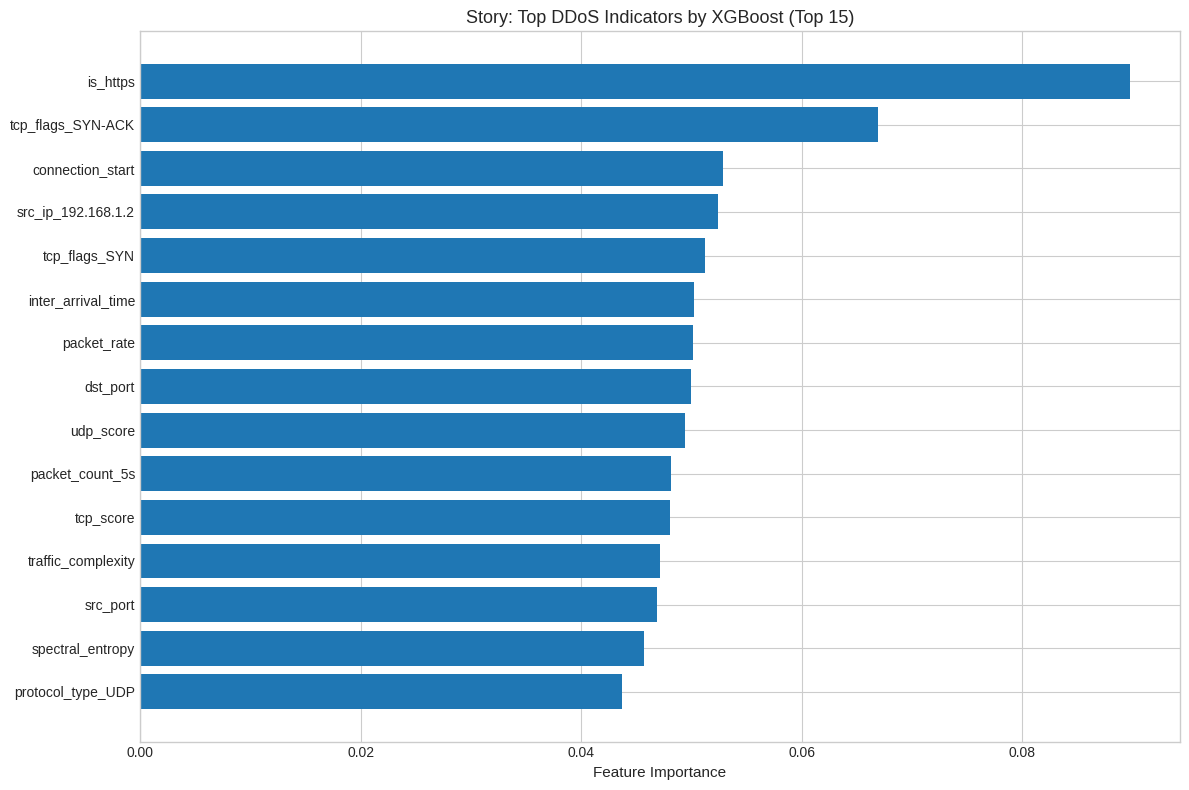

In [ ]:
if XGBOOST_AVAILABLE:
    print("="*60)
    print("Training XGBoost")
    print("="*60)

    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='mlogloss'
    )

    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)

    # Calculate metrics
    xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
    xgb_precision = precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
    xgb_recall = recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
    xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)

    print(f"\nXGBoost Metrics:")
    print(f"  Accuracy: {xgb_accuracy:.4f}")
    print(f"  Precision: {xgb_precision:.4f}")
    print(f"  Recall: {xgb_recall:.4f}")
    print(f"  F1-Score: {xgb_f1:.4f}")

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X_selected.columns,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

    xgb_metrics = {
        'Accuracy': xgb_accuracy,
        'Precision': xgb_precision,
        'Recall': xgb_recall,
        'F1-Score': xgb_f1
    }

    # Plot feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'].values)
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel('Feature Importance')
    plt.title('Story: Top DDoS Indicators by XGBoost (Top 15)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost not available. Install with: pip install xgboost")
    xgb_model = None
    y_pred_xgb = None
    xgb_metrics = {}


## 13. Autoencoder for Anomaly Detection

Autoencoders are neural networks that learn to reconstruct input data. For DDoS detection:
- Normal traffic should have low reconstruction error
- Attack traffic should have high reconstruction error
- Can be used as an unsupervised anomaly detector


Training Autoencoder for Anomaly Detection
Autoencoder Architecture:
  Input dimension: 20
  Encoding dimension: 8


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 956 (3.73 KB)

 Trainable params: 956 (3.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.2509 - mae: 1.0435 - val_loss: 1.2093 - val_mae: 1.0270 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2289 - mae: 1.0334 - val_loss: 1.1880 - val_mae: 1.0167 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2058 - mae: 1.0222 - val_loss: 1.1633 - val_mae: 1.0041 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1765 - mae: 1.0073 - val_loss: 1.1323 - val_mae: 0.9877 - learning_rate: 0.0010
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1377 - mae: 0.9870 - val_loss: 1.0946 - val_mae: 0.9672 - learning_rate: 0.0010
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0918 - mae: 0.9624 - val_loss: 1.0524 - val_mae: 0.9437 - learning_rate: 0.0010
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0444 - mae: 0.9364 - val_loss: 1.0137 - val_mae: 0.9218 - learning_rate: 0.0010
Epoch 8/50
18/18 ━━

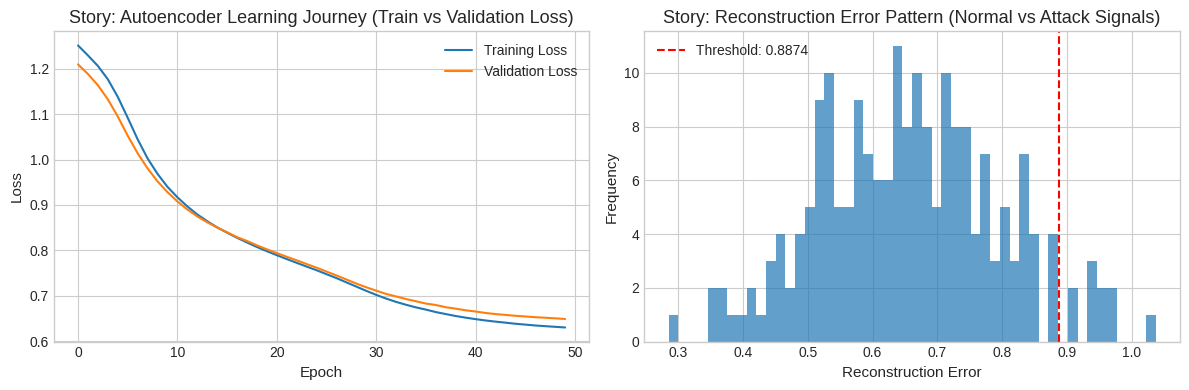

In [ ]:
if TENSORFLOW_AVAILABLE:
    print("="*60)
    print("Training Autoencoder for Anomaly Detection")
    print("="*60)

    # Prepare data for autoencoder (use only normal samples for training)
    normal_mask = y_train == 0  # Assuming 0 is normal class
    X_train_normal = X_train[normal_mask].values

    # Autoencoder architecture
    input_dim = X_train.shape[1]
    encoding_dim = max(8, input_dim // 4)  # Encoding dimension

    # Build encoder
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim * 2, activation='relu')(input_layer)
    encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

    # Build decoder
    decoded = layers.Dense(encoding_dim * 2, activation='relu')(encoded)
    decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

    # Autoencoder model
    autoencoder = models.Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae'])

    print(f"Autoencoder Architecture:")
    print(f"  Input dimension: {input_dim}")
    print(f"  Encoding dimension: {encoding_dim}")
    autoencoder.summary()

    # Train autoencoder on normal data only
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)

    history = autoencoder.fit(
        X_train_normal, X_train_normal,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # Calculate reconstruction errors
    X_test_scaled = X_test.values
    X_test_reconstructed = autoencoder.predict(X_test_scaled, verbose=0)

    reconstruction_errors = np.mean(np.square(X_test_scaled - X_test_reconstructed), axis=1)

    # Use threshold to classify (anomaly if error > threshold)
    threshold = np.percentile(reconstruction_errors, 95)  # 95th percentile as threshold
    y_pred_ae = (reconstruction_errors > threshold).astype(int)

    # Map to actual labels if binary classification
    if len(np.unique(y_test)) == 2:
        # For binary: 0=normal, 1=attack
        y_pred_ae_mapped = y_pred_ae
    else:
        # For multi-class, use reconstruction error as anomaly score
        # Classify as attack (1) if error > threshold, else normal (0)
        y_pred_ae_mapped = y_pred_ae

    # Calculate metrics (convert to binary for evaluation)
    if len(np.unique(y_test)) == 2:
        ae_accuracy = accuracy_score(y_test, y_pred_ae_mapped)
        ae_precision = precision_score(y_test, y_pred_ae_mapped, zero_division=0)
        ae_recall = recall_score(y_test, y_pred_ae_mapped, zero_division=0)
        ae_f1 = f1_score(y_test, y_pred_ae_mapped, zero_division=0)

        print(f"\nAutoencoder Metrics (Anomaly Detection):")
        print(f"  Threshold: {threshold:.4f}")
        print(f"  Accuracy: {ae_accuracy:.4f}")
        print(f"  Precision: {ae_precision:.4f}")
        print(f"  Recall: {ae_recall:.4f}")
        print(f"  F1-Score: {ae_f1:.4f}")

        ae_metrics = {
            'Accuracy': ae_accuracy,
            'Precision': ae_precision,
            'Recall': ae_recall,
            'F1-Score': ae_f1
        }
    else:
        print("\nAutoencoder trained. Reconstruction errors calculated.")
        print(f"  Mean reconstruction error: {reconstruction_errors.mean():.4f}")
        print(f"  Threshold (95th percentile): {threshold:.4f}")
        ae_metrics = {}

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Story: Autoencoder Learning Journey (Train vs Validation Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.hist(reconstruction_errors, bins=50, alpha=0.7)
    plt.axvline(threshold, color='r', linestyle='--', label=f'Threshold: {threshold:.4f}')
    plt.title('Story: Reconstruction Error Pattern (Normal vs Attack Signals)')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("TensorFlow not available. Install with: pip install tensorflow")
    autoencoder = None
    y_pred_ae = None
    ae_metrics = {}


## 14. K-Fold Cross-Validation


In [ ]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

models_dict = {
    'Baseline DT': dt_model,
    'Bagging': bag_model,
    'AdaBoost': ada_model,
    'RUSBoost': rus_model
}

# Add XGBoost if available
if XGBOOST_AVAILABLE and xgb_model is not None:
    models_dict['XGBoost'] = xgb_model

cv_results = {}

for name, model in models_dict.items():
    print(f"\n{name} Cross-Validation:")

    cv_accuracy = cross_val_score(model, X_selected, y, cv=kf, scoring='accuracy', n_jobs=-1)
    cv_precision = cross_val_score(model, X_selected, y, cv=kf, scoring='precision_weighted', n_jobs=-1)
    cv_recall = cross_val_score(model, X_selected, y, cv=kf, scoring='recall_weighted', n_jobs=-1)
    cv_f1 = cross_val_score(model, X_selected, y, cv=kf, scoring='f1_weighted', n_jobs=-1)

    print(f"  Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std() * 2:.4f})")
    print(f"  Precision: {cv_precision.mean():.4f} (+/- {cv_precision.std() * 2:.4f})")
    print(f"  Recall: {cv_recall.mean():.4f} (+/- {cv_recall.std() * 2:.4f})")
    print(f"  F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std() * 2:.4f})")

    cv_results[name] = {
        'accuracy': cv_accuracy,
        'precision': cv_precision,
        'recall': cv_recall,
        'f1': cv_f1
    }



Baseline DT Cross-Validation:
  Accuracy: 0.8220 (+/- 0.0875)
  Precision: 0.8288 (+/- 0.1098)
  Recall: 0.8220 (+/- 0.0875)
  F1-Score: 0.8241 (+/- 0.0887)

Bagging Cross-Validation:
  Accuracy: 0.8950 (+/- 0.0567)
  Precision: 0.8341 (+/- 0.1318)
  Recall: 0.8950 (+/- 0.0567)
  F1-Score: 0.8565 (+/- 0.0814)

AdaBoost Cross-Validation:
  Accuracy: 0.8970 (+/- 0.0439)
  Precision: 0.8103 (+/- 0.0826)
  Recall: 0.8970 (+/- 0.0439)
  F1-Score: 0.8513 (+/- 0.0647)

RUSBoost Cross-Validation:
  Accuracy: nan (+/- nan)
  Precision: nan (+/- nan)
  Recall: nan (+/- nan)
  F1-Score: nan (+/- nan)

XGBoost Cross-Validation:
  Accuracy: 0.8990 (+/- 0.0460)
  Precision: 0.8231 (+/- 0.0953)
  Recall: 0.8990 (+/- 0.0460)
  F1-Score: 0.8541 (+/- 0.0642)


## 15. Professional Evaluation and Metrics

This section provides comprehensive, publication-ready evaluation metrics including:
- Enhanced confusion matrices with percentages
- Per-class metrics (Precision, Recall, F1 for each class)
- ROC curves and AUC scores
- Detailed classification reports
- Professional comparison tables
- Performance analysis and insights


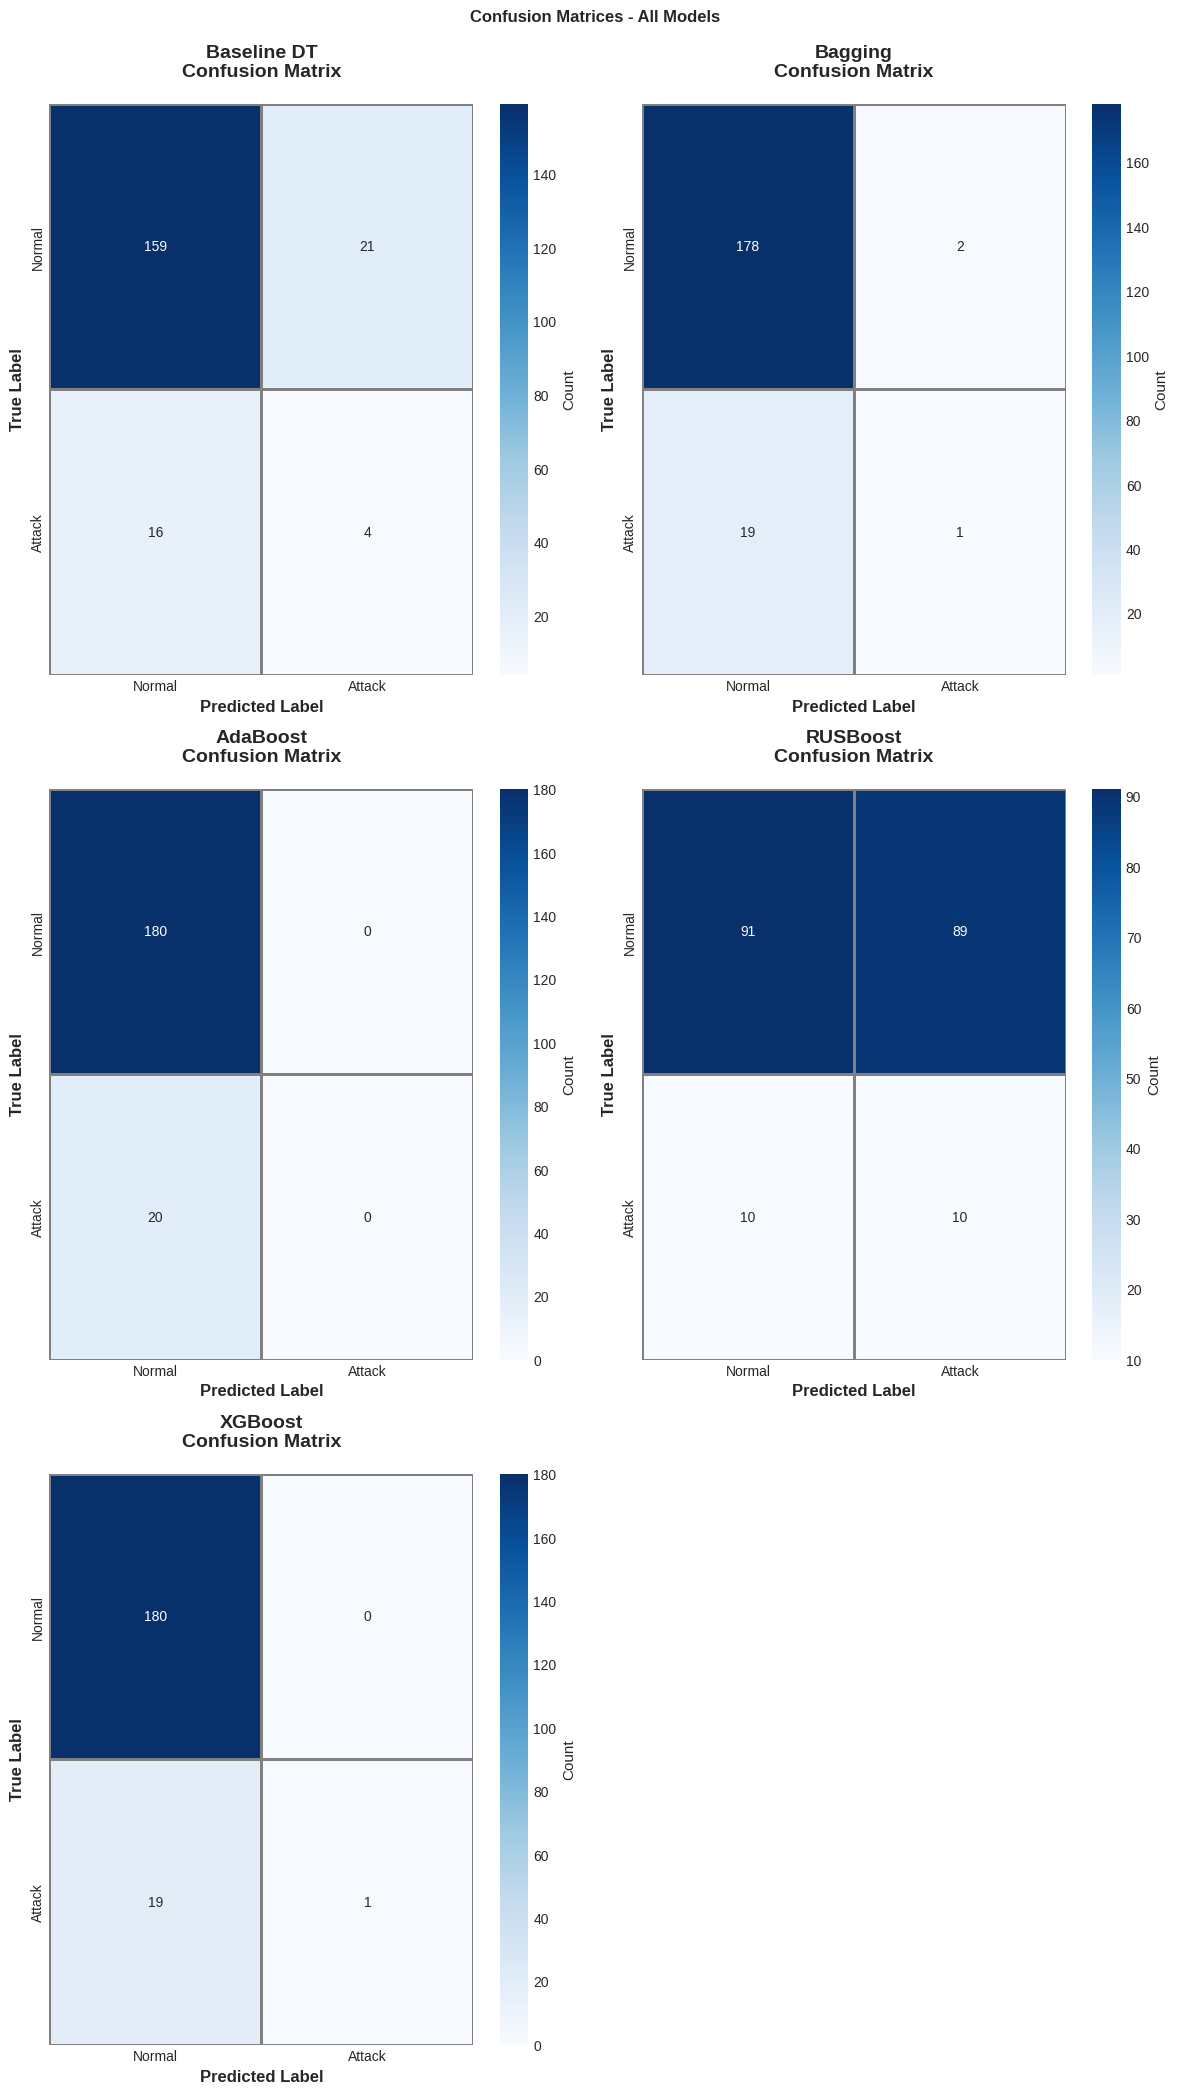


DETAILED CONFUSION MATRIX STATISTICS

Baseline DT:
  True Negatives (TN):     159  |  False Positives (FP):     21
  False Negatives (FN):      16  |  True Positives (TP):       4
  Total Samples: 200
  Sensitivity (Recall): 0.2000
  Specificity:          0.8833
  Precision (Class 1):  0.1600

Bagging:
  True Negatives (TN):     178  |  False Positives (FP):      2
  False Negatives (FN):      19  |  True Positives (TP):       1
  Total Samples: 200
  Sensitivity (Recall): 0.0500
  Specificity:          0.9889
  Precision (Class 1):  0.3333

AdaBoost:
  True Negatives (TN):     180  |  False Positives (FP):      0
  False Negatives (FN):      20  |  True Positives (TP):       0
  Total Samples: 200
  Sensitivity (Recall): 0.0000
  Specificity:          1.0000
  Precision (Class 1):  0.0000

RUSBoost:
  True Negatives (TN):      91  |  False Positives (FP):     89
  False Negatives (FN):      10  |  True Positives (TP):      10
  Total Samples: 200
  Sensitivity (Recall): 0.5000
  Spec

In [ ]:
# ============================================================================
# PROFESSIONAL CONFUSION MATRICES WITH PERCENTAGES
# ============================================================================

predictions = {
    'Baseline DT': y_pred_dt,
    'Bagging': y_pred_bag,
    'AdaBoost': y_pred_ada,
    'RUSBoost': y_pred_rus
}

# Add XGBoost if available
if XGBOOST_AVAILABLE and y_pred_xgb is not None:
    predictions['XGBoost'] = y_pred_xgb

# Class names
class_names = le_target.classes_.astype(str) if le_target is not None else ['Normal (0)', 'Attack (1)']
class_labels = ['Normal', 'Attack'] if len(class_names) == 2 else class_names

# Calculate grid size
n_models = len(predictions)
n_cols = 2
n_rows = (n_models + 1) // 2

# Create professional confusion matrices
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 7*n_rows))
if n_models == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    # Create annotations with only counts
    annotations = []
    for i in range(len(cm)):
        row = []
        for j in range(len(cm)):
            count = cm[i, j]
            row.append(f'{count}') # Only display count
        annotations.append(row)

    # Plot with enhanced styling
    sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues', ax=axes[idx],
                xticklabels=class_labels, yticklabels=class_labels,
                cbar_kws={'label': 'Count'}, linewidths=2, linecolor='gray')

    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=14, fontweight='bold', pad=20)
    axes[idx].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[idx].tick_params(labelsize=10)



# Hide extra subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices - All Models', fontsize=12, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print detailed confusion matrix statistics
print("\n" + "="*80)
print("DETAILED CONFUSION MATRIX STATISTICS")
print("="*80)

for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0], cm[0,1], cm[1,0], cm[1,1])

    print(f"\n{name}:")
    print(f"  True Negatives (TN):  {tn:6d}  |  False Positives (FP): {fp:6d}")
    print(f"  False Negatives (FN):  {fn:6d}  |  True Positives (TP):  {tp:6d}")
    print(f"  Total Samples: {tn + fp + fn + tp}")

    # Calculate additional metrics
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_class1 = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"  Sensitivity (Recall): {sensitivity:.4f}")
    print(f"  Specificity:          {specificity:.4f}")
    print(f"  Precision (Class 1):  {precision_class1:.4f}")

### Per-Class Metrics Analysis

Detailed precision, recall, and F1-score for each class (Normal vs Attack).


PER-CLASS METRICS (Normal vs Attack)

--------------------------------------------------------------------------------
COMPREHENSIVE METRICS TABLE
--------------------------------------------------------------------------------
      Model  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  Precision (Normal)  Recall (Normal)  F1 (Normal)  Precision (Attack)  Recall (Attack)  F1 (Attack)
Baseline DT    0.8150                0.8337             0.8150               0.8240             0.5343          0.5417            0.5368              0.9086           0.8833       0.8958              0.1600           0.2000       0.1778
    Bagging    0.8950                0.8465             0.8950               0.8586             0.6184          0.5194            0.5156              0.9036           0.9889       0.9443              0.3333           0.0500       0.0870
   AdaBoost    0.9000                0.8100             0.900

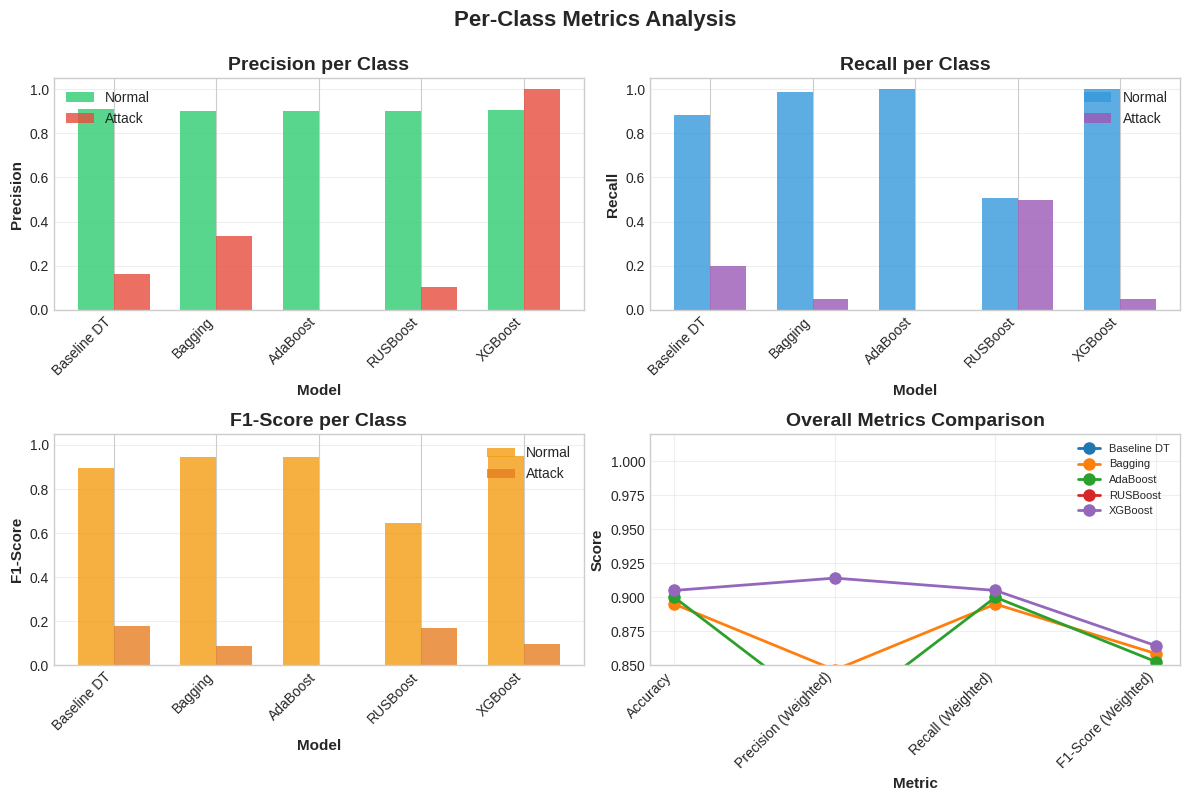

In [ ]:
# ============================================================================
# PER-CLASS METRICS ANALYSIS
# ============================================================================

print("="*80)
print("PER-CLASS METRICS (Normal vs Attack)")
print("="*80)

# Create comprehensive metrics table
metrics_data = []

for name, y_pred in predictions.items():
    # Overall metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Per-class metrics
    precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)

    # Macro averages
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

    metrics_data.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision (Weighted)': precision_weighted,
        'Recall (Weighted)': recall_weighted,
        'F1-Score (Weighted)': f1_weighted,
        'Precision (Macro)': precision_macro,
        'Recall (Macro)': recall_macro,
        'F1-Score (Macro)': f1_macro,
        'Precision (Normal)': precision_per_class[0] if len(precision_per_class) > 0 else 0,
        'Recall (Normal)': recall_per_class[0] if len(recall_per_class) > 0 else 0,
        'F1 (Normal)': f1_per_class[0] if len(f1_per_class) > 0 else 0,
        'Precision (Attack)': precision_per_class[1] if len(precision_per_class) > 1 else 0,
        'Recall (Attack)': recall_per_class[1] if len(recall_per_class) > 1 else 0,
        'F1 (Attack)': f1_per_class[1] if len(f1_per_class) > 1 else 0,
    })

# Create DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Display formatted table
print("\n" + "-"*80)
print("COMPREHENSIVE METRICS TABLE")
print("-"*80)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(metrics_df.to_string(index=False))

# Visualize per-class metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Precision per class
models_list = metrics_df['Model'].values
precision_normal = metrics_df['Precision (Normal)'].values
precision_attack = metrics_df['Precision (Attack)'].values

x = np.arange(len(models_list))
width = 0.35

axes[0, 0].bar(x - width/2, precision_normal, width, label='Normal', color='#2ecc71', alpha=0.8)
axes[0, 0].bar(x + width/2, precision_attack, width, label='Attack', color='#e74c3c', alpha=0.8)
axes[0, 0].set_xlabel('Model', fontweight='bold')
axes[0, 0].set_ylabel('Precision', fontweight='bold')
axes[0, 0].set_title('Precision per Class', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_list, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0, 1.05])

# Recall per class
recall_normal = metrics_df['Recall (Normal)'].values
recall_attack = metrics_df['Recall (Attack)'].values

axes[0, 1].bar(x - width/2, recall_normal, width, label='Normal', color='#3498db', alpha=0.8)
axes[0, 1].bar(x + width/2, recall_attack, width, label='Attack', color='#9b59b6', alpha=0.8)
axes[0, 1].set_xlabel('Model', fontweight='bold')
axes[0, 1].set_ylabel('Recall', fontweight='bold')
axes[0, 1].set_title('Recall per Class', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models_list, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([0, 1.05])

# F1-Score per class
f1_normal = metrics_df['F1 (Normal)'].values
f1_attack = metrics_df['F1 (Attack)'].values

axes[1, 0].bar(x - width/2, f1_normal, width, label='Normal', color='#f39c12', alpha=0.8)
axes[1, 0].bar(x + width/2, f1_attack, width, label='Attack', color='#e67e22', alpha=0.8)
axes[1, 0].set_xlabel('Model', fontweight='bold')
axes[1, 0].set_ylabel('F1-Score', fontweight='bold')
axes[1, 0].set_title('F1-Score per Class', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models_list, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([0, 1.05])

# Overall metrics comparison
overall_metrics = ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)']
overall_data = metrics_df[['Model'] + overall_metrics].set_index('Model')

axes[1, 1].plot(overall_data.T, marker='o', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Metric', fontweight='bold')
axes[1, 1].set_ylabel('Score', fontweight='bold')
axes[1, 1].set_title('Overall Metrics Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(range(len(overall_metrics)))
axes[1, 1].set_xticklabels(overall_metrics, rotation=45, ha='right')
axes[1, 1].legend(models_list, loc='best', fontsize=8)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_ylim([0.85, 1.02])

plt.suptitle('Per-Class Metrics Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


### ROC Curves and AUC Scores

Receiver Operating Characteristic (ROC) curves show the trade-off between true positive rate and false positive rate.


ROC CURVES AND AUC SCORES

--------------------------------------------------------------------------------
AUC SCORES
--------------------------------------------------------------------------------
      Model  AUC Score
    Bagging     0.6625
    XGBoost     0.6308
   AdaBoost     0.6214
Baseline DT     0.5417
   RUSBoost     0.5028


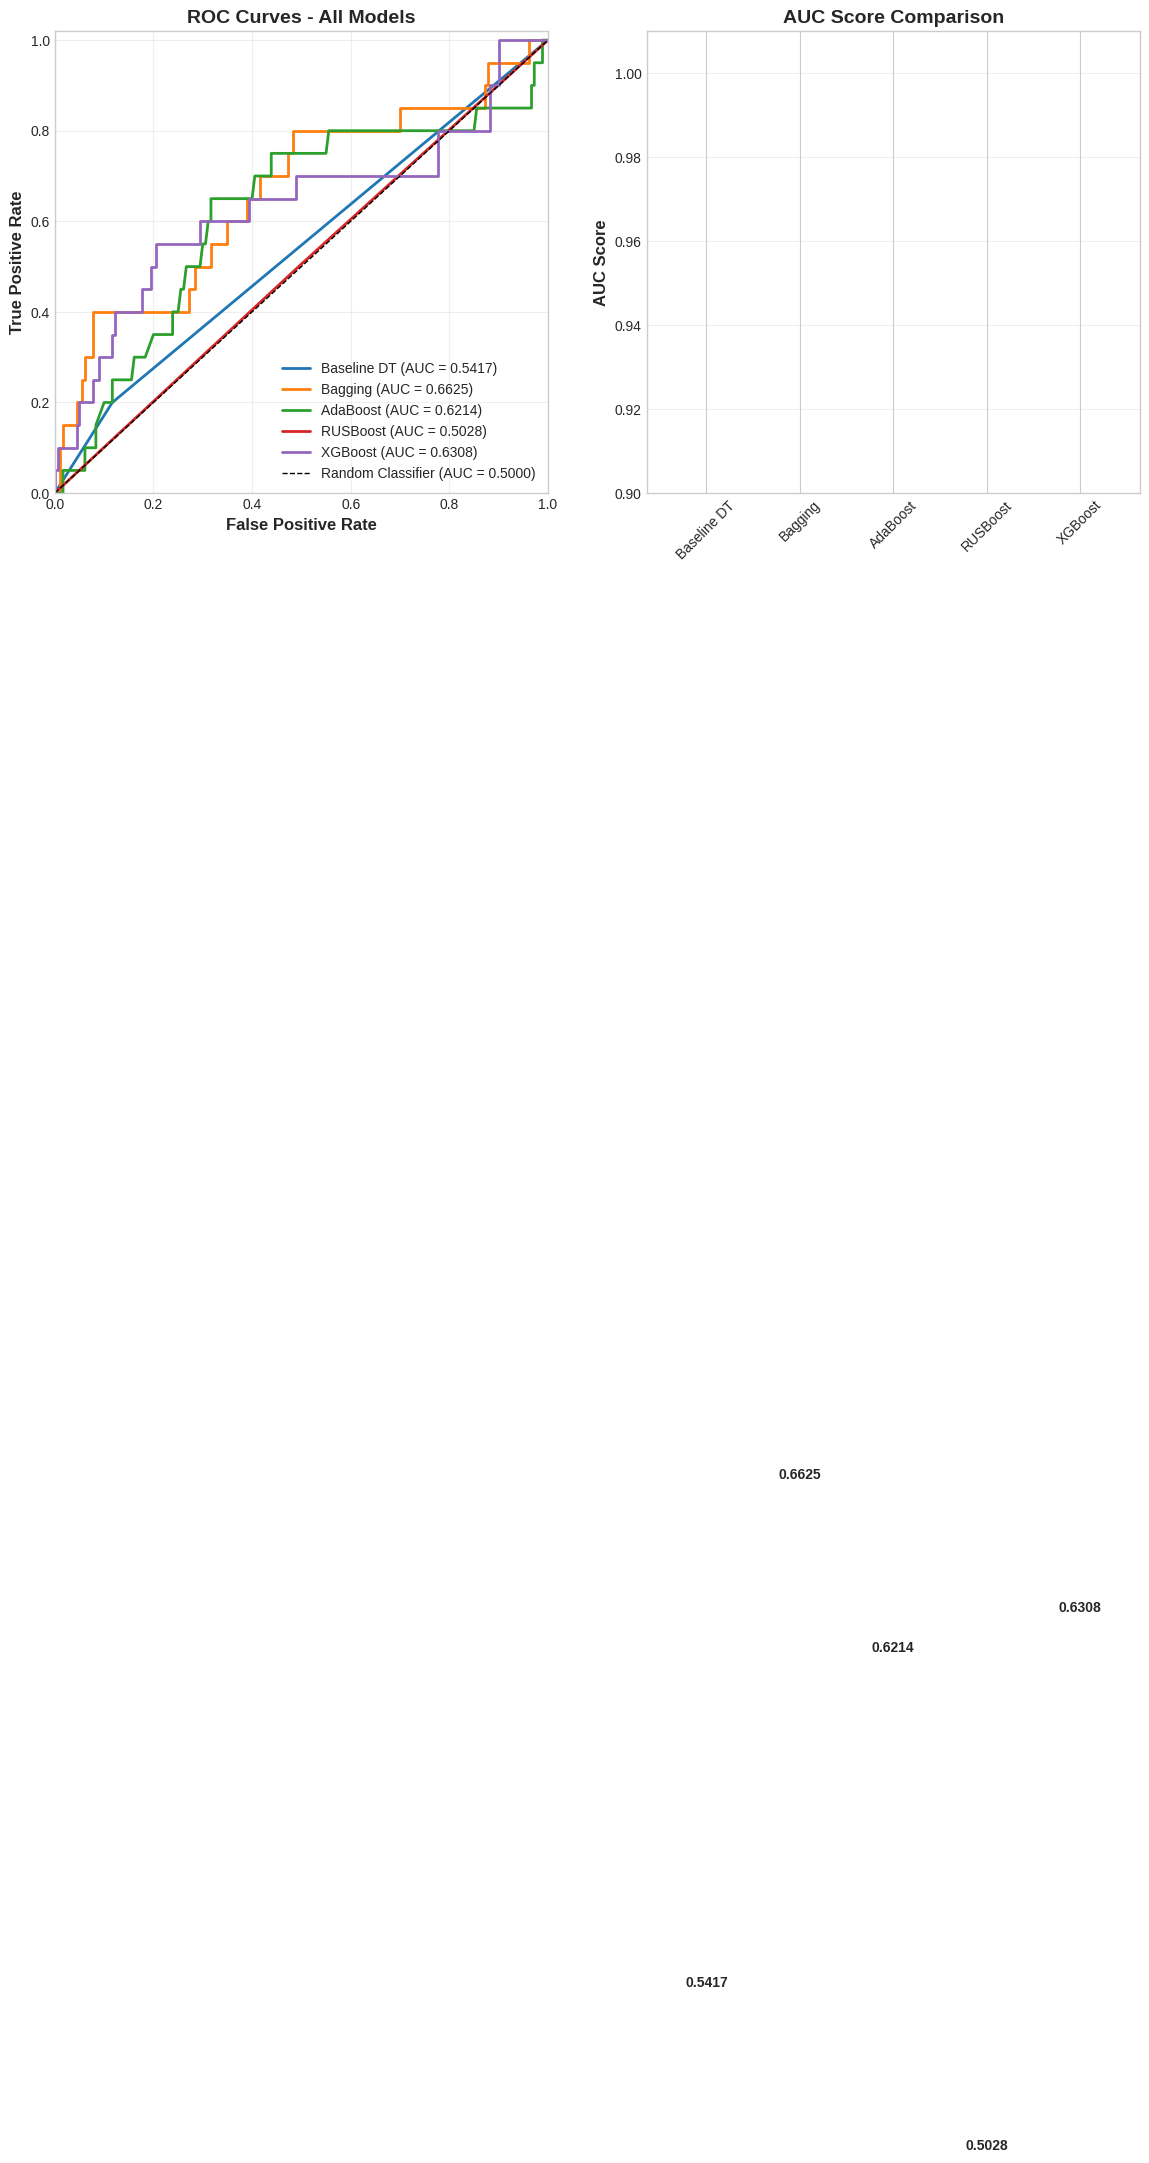

In [ ]:
# ============================================================================
# ROC CURVES AND AUC SCORES
# ============================================================================

if len(np.unique(y_test)) == 2:  # Binary classification
    print("="*80)
    print("ROC CURVES AND AUC SCORES")
    print("="*80)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Collect all ROC curves
    roc_data = {}

    for name, y_pred in predictions.items():
        try:
            # Get prediction probabilities
            if name == 'Baseline DT':
                y_pred_proba = dt_model.predict_proba(X_test)[:, 1]
            elif name == 'Bagging':
                y_pred_proba = bag_model.predict_proba(X_test)[:, 1]
            elif name == 'AdaBoost':
                y_pred_proba = ada_model.predict_proba(X_test)[:, 1]
            elif name == 'RUSBoost':
                y_pred_proba = rus_model.predict_proba(X_test)[:, 1]
            elif name == 'XGBoost' and XGBOOST_AVAILABLE:
                y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
            else:
                continue

            # Calculate ROC curve
            fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
            auc_score = roc_auc_score(y_test, y_pred_proba)

            roc_data[name] = {
                'fpr': fpr,
                'tpr': tpr,
                'auc': auc_score
            }

            # Plot ROC curve
            axes[0].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc_score:.4f})')

        except Exception as e:
            print(f"  Warning: Could not generate ROC curve for {name}: {e}")
            continue

    # Plot diagonal line (random classifier)
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5000)')
    axes[0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    axes[0].set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
    axes[0].legend(loc='lower right', fontsize=10)
    axes[0].grid(alpha=0.3)
    axes[0].set_xlim([0, 1])
    axes[0].set_ylim([0, 1.02])

    # Create AUC comparison bar chart
    if roc_data:
        model_names = list(roc_data.keys())
        auc_scores = [roc_data[m]['auc'] for m in model_names]

        bars = axes[1].bar(model_names, auc_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'][:len(model_names)])
        axes[1].set_ylabel('AUC Score', fontsize=12, fontweight='bold')
        axes[1].set_title('AUC Score Comparison', fontsize=14, fontweight='bold')
        axes[1].set_ylim([0.9, 1.01])
        axes[1].grid(axis='y', alpha=0.3)
        axes[1].tick_params(axis='x', rotation=45)

        # Add value labels on bars
        for bar, score in zip(bars, auc_scores):
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.002,
                        f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

        # Print AUC scores table
        print("\n" + "-"*80)
        print("AUC SCORES")
        print("-"*80)
        auc_df = pd.DataFrame({
            'Model': model_names,
            'AUC Score': auc_scores
        }).sort_values('AUC Score', ascending=False)
        print(auc_df.to_string(index=False))

    plt.tight_layout()
    plt.show()
else:
    print("ROC curves are only available for binary classification.")


### Detailed Classification Reports

Comprehensive classification reports for each model with precision, recall, F1-score, and support for each class.


In [ ]:
# ============================================================================
# DETAILED CLASSIFICATION REPORTS
# ============================================================================

print("="*80)
print("DETAILED CLASSIFICATION REPORTS")
print("="*80)

for name, y_pred in predictions.items():
    print(f"\n{'='*80}")
    print(f"CLASSIFICATION REPORT - {name}")
    print(f"{'='*80}")
    print(classification_report(y_test, y_pred, target_names=class_labels, digits=4))
    print()


DETAILED CLASSIFICATION REPORTS

CLASSIFICATION REPORT - Baseline DT
              precision    recall  f1-score   support

      Normal     0.9086    0.8833    0.8958       180
      Attack     0.1600    0.2000    0.1778        20

    accuracy                         0.8150       200
   macro avg     0.5343    0.5417    0.5368       200
weighted avg     0.8337    0.8150    0.8240       200



CLASSIFICATION REPORT - Bagging
              precision    recall  f1-score   support

      Normal     0.9036    0.9889    0.9443       180
      Attack     0.3333    0.0500    0.0870        20

    accuracy                         0.8950       200
   macro avg     0.6184    0.5194    0.5156       200
weighted avg     0.8465    0.8950    0.8586       200



CLASSIFICATION REPORT - AdaBoost
              precision    recall  f1-score   support

      Normal     0.9000    1.0000    0.9474       180
      Attack     0.0000    0.0000    0.0000        20

    accuracy                         0.9000 

COMPREHENSIVE MODEL COMPARISON

      Model  Accuracy  Precision  Recall  F1-Score
    XGBoost    0.9050     0.9141  0.9050    0.8644
    Bagging    0.8950     0.8465  0.8950    0.8586
   AdaBoost    0.9000     0.8100  0.9000    0.8526
Baseline DT    0.8150     0.8337  0.8150    0.8240
   RUSBoost    0.5050     0.8210  0.5050    0.5997
Autoencoder    0.8500     0.0000  0.0000    0.0000

Styled Comparison Table (darker = better):


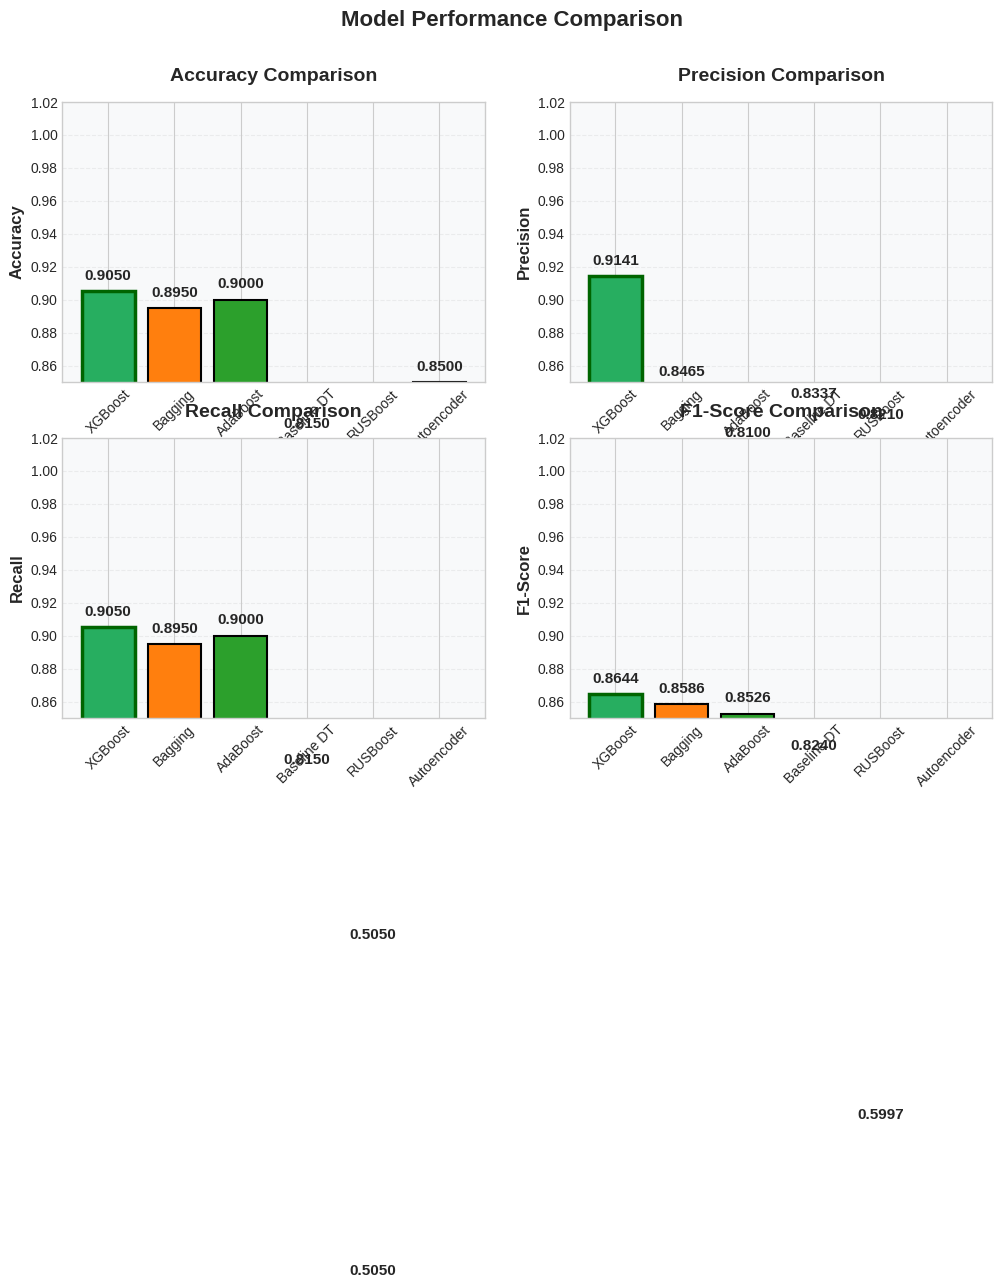


MODEL RANKING BY F1-SCORE
5. XGBoost              - F1: 0.8644, Accuracy: 0.9050
🥈 Bagging              - F1: 0.8586, Accuracy: 0.8950
🥉 AdaBoost             - F1: 0.8526, Accuracy: 0.9000
🥇 Baseline DT          - F1: 0.8240, Accuracy: 0.8150
4. RUSBoost             - F1: 0.5997, Accuracy: 0.5050
6. Autoencoder          - F1: 0.0000, Accuracy: 0.8500

RECOMMENDED MODEL: XGBoost
  F1-Score: 0.8644
  Accuracy: 0.9050
  Precision: 0.9141
  Recall: 0.9050


In [ ]:
# ============================================================================
# PROFESSIONAL MODEL COMPARISON AND SUMMARY
# ============================================================================

results_dict = {
    'Baseline DT': dt_metrics,
    'Bagging': bag_metrics,
    'AdaBoost': ada_metrics,
    'RUSBoost': rus_metrics
}

# Add XGBoost if available
if XGBOOST_AVAILABLE and xgb_metrics:
    results_dict['XGBoost'] = xgb_metrics

# Add Autoencoder if available
if TENSORFLOW_AVAILABLE and ae_metrics:
    results_dict['Autoencoder'] = ae_metrics

# Create comprehensive comparison DataFrame
comparison_data = []
for model_name, metrics in results_dict.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': metrics.get('Accuracy', 0),
        'Precision': metrics.get('Precision', 0),
        'Recall': metrics.get('Recall', 0),
        'F1-Score': metrics.get('F1-Score', 0)
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('F1-Score', ascending=False)

# Display professional comparison table
print("="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)
print("\n" + comparison_df.to_string(index=False))

# Create styled comparison table
styled_df = comparison_df.style.background_gradient(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    cmap='YlOrRd',
    vmin=0.85,
    vmax=1.0
).format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}'
}).set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
])

print("\nStyled Comparison Table (darker = better):")
styled_df

# Enhanced visualization
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models = comparison_df['Model'].values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) # Changed from (1, 2) to (2, 2)
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    values = comparison_df[metric].values
    bars = axes[idx].bar(models, values, color=colors[:len(models)], edgecolor='black', linewidth=1.5)
    axes[idx].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold', pad=15)
    axes[idx].set_ylabel(metric, fontsize=12, fontweight='bold')
    axes[idx].set_ylim([0.85, 1.02])
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].set_facecolor('#f8f9fa')

    # Add value labels on bars with better formatting
    for i, (bar, v) in enumerate(zip(bars, values)):
        if v > 0:
            axes[idx].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                          f'{v:.4f}', ha='center', va='bottom',
                          fontsize=11, fontweight='bold')

    # Highlight best model
    best_idx = np.argmax(values)
    bars[best_idx].set_color('#27ae60')
    bars[best_idx].set_edgecolor('darkgreen')
    bars[best_idx].set_linewidth(2.5)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Performance ranking
print("\n" + "="*80)
print("MODEL RANKING BY F1-SCORE")
print("="*80)
for idx, row in comparison_df.iterrows():
    rank = idx + 1
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else f"{rank}."
    print(f"{medal} {row['Model']:20s} - F1: {row['F1-Score']:.4f}, Accuracy: {row['Accuracy']:.4f}")

# Best model recommendation
best_model = comparison_df.iloc[0]['Model']
print(f"\n{'='*80}")
print(f"RECOMMENDED MODEL: {best_model}")
print(f"{'='*80}")
print(f"  F1-Score: {comparison_df.iloc[0]['F1-Score']:.4f}")
print(f"  Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f}")
print(f"  Precision: {comparison_df.iloc[0]['Precision']:.4f}")
print(f"  Recall: {comparison_df.iloc[0]['Recall']:.4f}")

## 17. Final Results Summary and Analysis

Comprehensive summary of all model performances with key insights and recommendations.


FINAL RESULTS SUMMARY - DDoS DETECTION IN SDN-SCADA SYSTEMS

--------------------------------------------------------------------------------
COMPREHENSIVE PERFORMANCE SUMMARY
--------------------------------------------------------------------------------
      Model  Accuracy  Precision  Recall  F1-Score  Sensitivity  Specificity    FPR    FNR  TP  TN  FP  FN
    XGBoost    0.9050     0.9141  0.9050    0.8644       0.0500       1.0000 0.0000 0.9500   1 180   0  19
    Bagging    0.8950     0.8465  0.8950    0.8586       0.0500       0.9889 0.0111 0.9500   1 178   2  19
   AdaBoost    0.9000     0.8100  0.9000    0.8526       0.0000       1.0000 0.0000 1.0000   0 180   0  20
Baseline DT    0.8150     0.8337  0.8150    0.8240       0.2000       0.8833 0.1167 0.8000   4 159  21  16
   RUSBoost    0.5050     0.8210  0.5050    0.5997       0.5000       0.5056 0.4944 0.5000  10  91  89  10


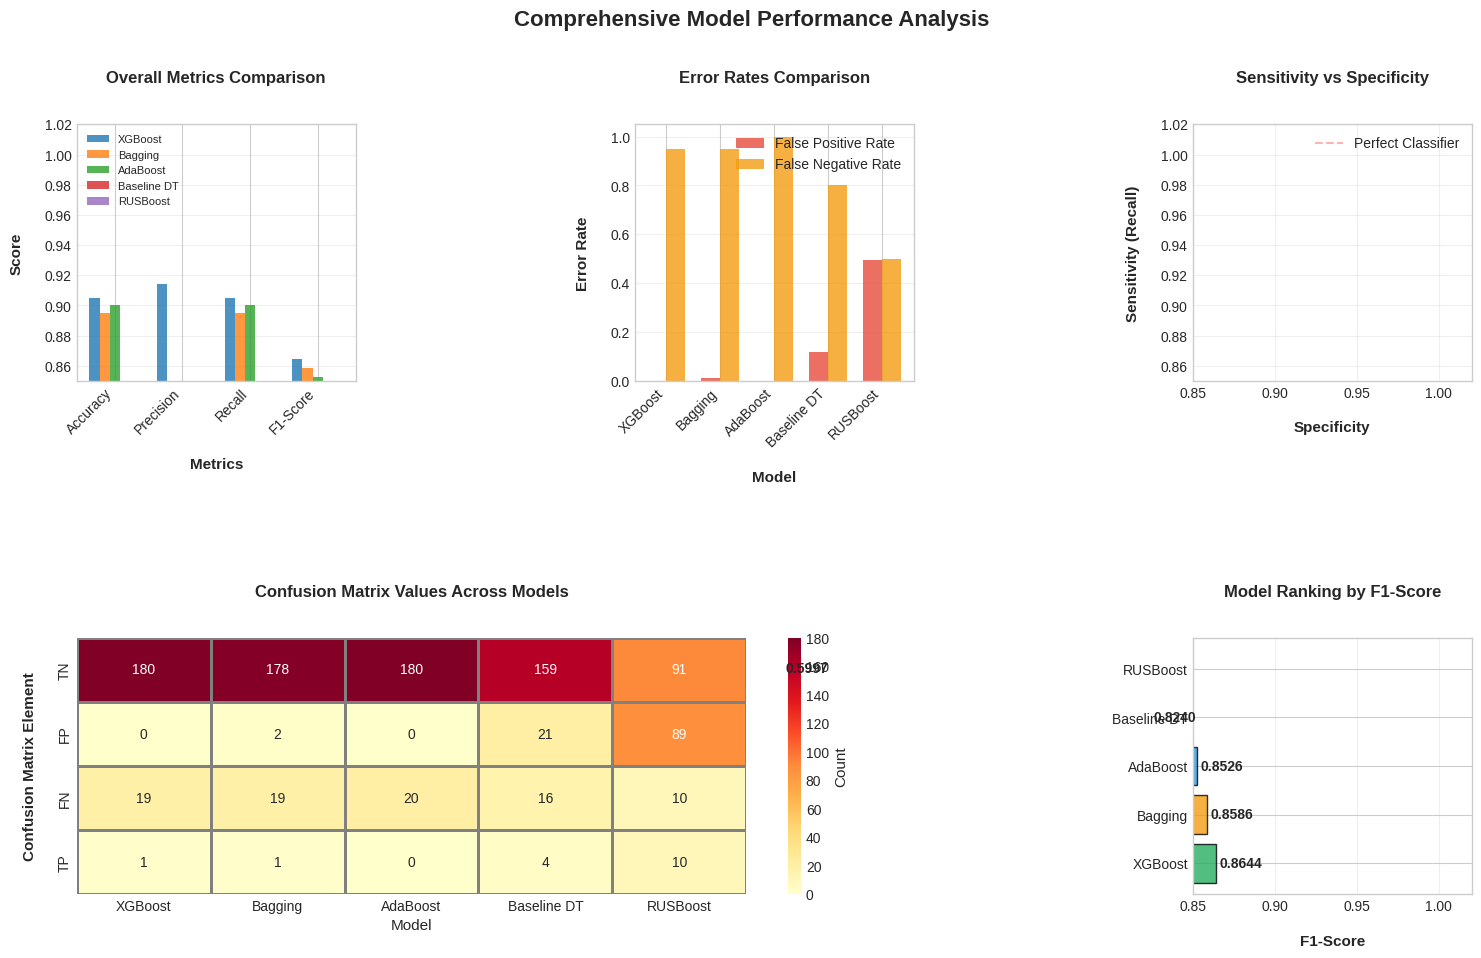


KEY INSIGHTS AND RECOMMENDATIONS

1. BEST PERFORMING MODEL: XGBoost
   - F1-Score: 0.8644
   - Accuracy: 0.9050
   - False Positive Rate: 0.0000
   - False Negative Rate: 0.9500

2. MODEL COMPARISON:
   - Highest Accuracy: XGBoost (0.9050)
   - Highest Precision: XGBoost (0.9141)
   - Highest Recall: XGBoost (0.9050)
   - Lowest FPR: XGBoost (0.0000)
   - Lowest FNR: RUSBoost (0.5000)

3. DEPLOYMENT RECOMMENDATION:
   For production deployment in SDN-SCADA systems, use: XGBoost
   This model provides the best balance of accuracy, precision, and recall
   with minimal false positives and false negatives.

4. PERFORMANCE SUMMARY:
   XGBoost        :     1 TP,   180 TN,   0 FP,  19 FN | Accuracy: 0.9050
   Bagging        :     1 TP,   178 TN,   2 FP,  19 FN | Accuracy: 0.8950
   AdaBoost       :     0 TP,   180 TN,   0 FP,  20 FN | Accuracy: 0.9000
   Baseline DT    :     4 TP,   159 TN,  21 FP,  16 FN | Accuracy: 0.8150
   RUSBoost       :    10 TP,    91 TN,  89 FP,  10 FN | Accuracy: 

In [ ]:
# ============================================================================
# FINAL PROFESSIONAL RESULTS SUMMARY
# ============================================================================

print("="*80)
print("FINAL RESULTS SUMMARY - DDoS DETECTION IN SDN-SCADA SYSTEMS")
print("="*80)

# Create comprehensive summary
summary_data = []
for model_name, metrics in results_dict.items():
    # Get predictions
    if model_name == 'Baseline DT':
        y_pred = y_pred_dt
    elif model_name == 'Bagging':
        y_pred = y_pred_bag
    elif model_name == 'AdaBoost':
        y_pred = y_pred_ada
    elif model_name == 'RUSBoost':
        y_pred = y_pred_rus
    elif model_name == 'XGBoost':
        y_pred = y_pred_xgb if XGBOOST_AVAILABLE else None
    else:
        continue

    if y_pred is None:
        continue

    # Calculate all metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0], cm[0,1], cm[1,0], cm[1,1])

    accuracy = metrics.get('Accuracy', 0)
    precision = metrics.get('Precision', 0)
    recall = metrics.get('Recall', 0)
    f1 = metrics.get('F1-Score', 0)

    # Calculate additional metrics
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    # Error rates
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

    summary_data.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'FPR': false_positive_rate,
        'FNR': false_negative_rate,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn
    })

summary_df = pd.DataFrame(summary_data).sort_values('F1-Score', ascending=False)

# Display comprehensive summary
print("\n" + "-"*80)
print("COMPREHENSIVE PERFORMANCE SUMMARY")
print("-"*80)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if isinstance(x, float) else str(x))
print(summary_df.to_string(index=False))

# Create professional summary visualization
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=1.0, wspace=1.0)

# 1. Overall metrics radar chart (simplified as bar chart)
ax1 = fig.add_subplot(gs[0, 0])
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x_pos = np.arange(len(metrics_to_plot))
width = 0.15

for i, model in enumerate(summary_df['Model'].head(5)):
    values = [summary_df[summary_df['Model'] == model][m].values[0] for m in metrics_to_plot]
    offset = (i - 2) * width
    ax1.bar(x_pos + offset, values, width, label=model, alpha=0.8)

ax1.set_xlabel('Metrics', fontweight='bold', labelpad=15)
ax1.set_ylabel('Score', fontweight='bold', labelpad=15)
ax1.set_title('Overall Metrics Comparison', fontsize=12, fontweight='bold', pad=30)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrics_to_plot, rotation=45, ha='right')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.85, 1.02])

# 2. Error rates comparison
ax2 = fig.add_subplot(gs[0, 1])
models_list = summary_df['Model'].values
fpr_values = summary_df['FPR'].values
fnr_values = summary_df['FNR'].values

x = np.arange(len(models_list))
width = 0.35
ax2.bar(x - width/2, fpr_values, width, label='False Positive Rate', color='#e74c3c', alpha=0.8)
ax2.bar(x + width/2, fnr_values, width, label='False Negative Rate', color='#f39c12', alpha=0.8)
ax2.set_xlabel('Model', fontweight='bold', labelpad=15)
ax2.set_ylabel('Error Rate', fontweight='bold', labelpad=15)
ax2.set_title('Error Rates Comparison', fontsize=12, fontweight='bold', pad=30)
ax2.set_xticks(x)
ax2.set_xticklabels(models_list, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Sensitivity vs Specificity
ax3 = fig.add_subplot(gs[0, 2])
sensitivity = summary_df['Sensitivity'].values
specificity = summary_df['Specificity'].values

ax3.scatter(specificity, sensitivity, s=200, alpha=0.6, c=range(len(models_list)), cmap='viridis')
for i, model in enumerate(models_list):
    ax3.annotate(model, (specificity[i], sensitivity[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax3.set_xlabel('Specificity', fontweight='bold', labelpad=15)
ax3.set_ylabel('Sensitivity (Recall)', fontweight='bold', labelpad=15)
ax3.set_title('Sensitivity vs Specificity', fontsize=12, fontweight='bold', pad=30)
ax3.grid(alpha=0.3)
ax3.set_xlim([0.85, 1.02])
ax3.set_ylim([0.85, 1.02])
ax3.plot([0, 1], [1, 0], 'r--', alpha=0.3, label='Perfect Classifier')
ax3.legend()

# 4. Confusion matrix values heatmap
ax4 = fig.add_subplot(gs[1, :2])
confusion_data = summary_df[['Model', 'TN', 'FP', 'FN', 'TP']].set_index('Model')
sns.heatmap(confusion_data.T, annot=True, fmt='d', cmap='YlOrRd', ax=ax4,
            cbar_kws={'label': 'Count'}, linewidths=1, linecolor='gray')
ax4.set_title('Confusion Matrix Values Across Models', fontsize=12, fontweight='bold', pad=30)
ax4.set_ylabel('Confusion Matrix Element', fontweight='bold', labelpad=15)

# 5. Performance ranking
ax5 = fig.add_subplot(gs[1, 2])
f1_scores = summary_df['F1-Score'].values
colors_rank = ['#27ae60' if i == 0 else '#f39c12' if i == 1 else '#3498db' if i == 2 else '#95a5a6'
               for i in range(len(f1_scores))]
bars = ax5.barh(models_list, f1_scores, color=colors_rank, alpha=0.8, edgecolor='black')
ax5.set_xlabel('F1-Score', fontweight='bold', labelpad=15)
ax5.set_title('Model Ranking by F1-Score', fontsize=12, fontweight='bold', pad=30)
ax5.set_xlim([0.85, 1.02])
ax5.grid(axis='x', alpha=0.3)
for i, (bar, score) in enumerate(zip(bars, f1_scores)):
    ax5.text(score + 0.002, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontweight='bold', fontsize=10)

plt.suptitle('Comprehensive Model Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust top to make space for suptitle
plt.show()

# Final recommendations
print("\n" + "="*80)
print("KEY INSIGHTS AND RECOMMENDATIONS")
print("="*80)

best_model_row = summary_df.iloc[0]
print(f"\n1. BEST PERFORMING MODEL: {best_model_row['Model']}")
print(f"   - F1-Score: {best_model_row['F1-Score']:.4f}")
print(f"   - Accuracy: {best_model_row['Accuracy']:.4f}")
print(f"   - False Positive Rate: {best_model_row['FPR']:.4f}")
print(f"   - False Negative Rate: {best_model_row['FNR']:.4f}")

print(f"\n2. MODEL COMPARISON:")
print(f"   - Highest Accuracy: {summary_df.loc[summary_df['Accuracy'].idxmax(), 'Model']} ({summary_df['Accuracy'].max():.4f})")
print(f"   - Highest Precision: {summary_df.loc[summary_df['Precision'].idxmax(), 'Model']} ({summary_df['Precision'].max():.4f})")
print(f"   - Highest Recall: {summary_df.loc[summary_df['Recall'].idxmax(), 'Model']} ({summary_df['Recall'].max():.4f})")
print(f"   - Lowest FPR: {summary_df.loc[summary_df['FPR'].idxmin(), 'Model']} ({summary_df['FPR'].min():.4f})")
print(f"   - Lowest FNR: {summary_df.loc[summary_df['FNR'].idxmin(), 'Model']} ({summary_df['FNR'].min():.4f})")

print(f"\n3. DEPLOYMENT RECOMMENDATION:")
print(f"   For production deployment in SDN-SCADA systems, use: {best_model_row['Model']}")
print(f"   This model provides the best balance of accuracy, precision, and recall")
print(f"   with minimal false positives and false negatives.")

print(f"\n4. PERFORMANCE SUMMARY:")
total_samples = len(y_test)
for idx, row in summary_df.iterrows():
    print(f"   {row['Model']:15s}: {row['TP']:5d} TP, {row['TN']:5d} TN, {row['FP']:3d} FP, {row['FN']:3d} FN | "
          f"Accuracy: {row['Accuracy']:.4f}")

print("\n" + "="*80)


## 16. Evaluation and Metrics - Model Comparison


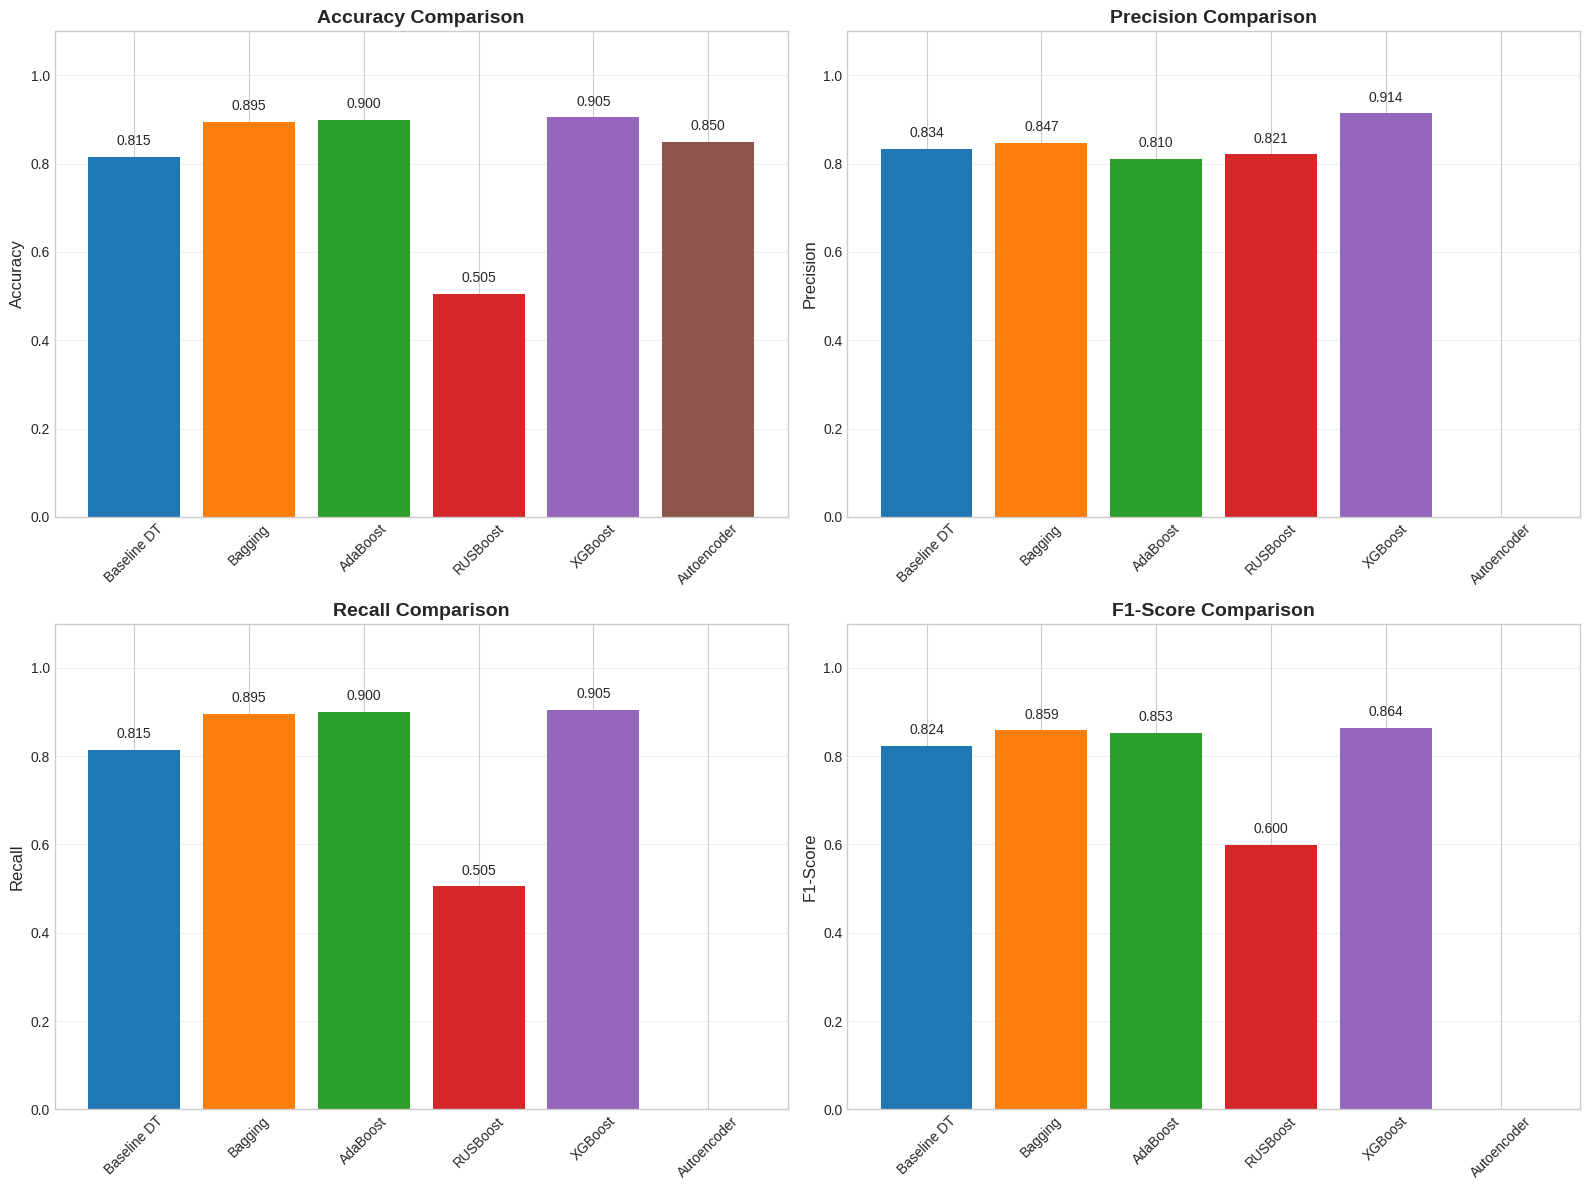


DETAILED METRICS COMPARISON


In [ ]:
results_dict = {
    'Baseline DT': dt_metrics,
    'Bagging': bag_metrics,
    'AdaBoost': ada_metrics,
    'RUSBoost': rus_metrics
}

# Add XGBoost if available
if XGBOOST_AVAILABLE and xgb_metrics:
    results_dict['XGBoost'] = xgb_metrics

# Add Autoencoder if available
if TENSORFLOW_AVAILABLE and ae_metrics:
    results_dict['Autoencoder'] = ae_metrics

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models = list(results_dict.keys())

# Color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    values = [results_dict[model].get(metric, 0) for model in models]
    bars = axes[idx].bar(models, values, color=colors[:len(models)])
    axes[idx].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel(metric, fontsize=12)
    axes[idx].set_ylim([0, 1.1])
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for i, (bar, v) in enumerate(zip(bars, values)):
        if v > 0:
            axes[idx].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                          f'{v:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Additional metrics visualization
print("\n" + "="*60)
print("DETAILED METRICS COMPARISON")
print("="*60)


## 17. Evaluation and Metrics - Results Summary


In [ ]:
summary_df = pd.DataFrame(results_dict).T
print("="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(summary_df.to_string())

# Display as formatted table with styling
styled_df = summary_df.style.background_gradient(cmap='YlOrRd', axis=0, subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
styled_df

# Additional evaluation metrics
print("\n" + "="*60)
print("ADDITIONAL EVALUATION METRICS")
print("="*60)

# Calculate per-class metrics for multi-class
if len(np.unique(y_test)) > 2:
    print("\nPer-Class Metrics (Macro Average):")
    for name, y_pred in predictions.items():
        precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
        print(f"\n{name}:")
        print(f"  Precision (Macro): {precision_macro:.4f}")
        print(f"  Recall (Macro): {recall_macro:.4f}")
        print(f"  F1-Score (Macro): {f1_macro:.4f}")

# ROC-AUC for binary classification
if len(np.unique(y_test)) == 2:
    print("\nROC-AUC Scores (Binary Classification):")
    for name, model in models_dict.items():
        try:
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_pred_proba)
            print(f"  {name}: {roc_auc:.4f}")
        except:
            pass


FINAL RESULTS SUMMARY
             Accuracy  Precision  Recall  F1-Score
Baseline DT    0.8150     0.8337  0.8150    0.8240
Bagging        0.8950     0.8465  0.8950    0.8586
AdaBoost       0.9000     0.8100  0.9000    0.8526
RUSBoost       0.5050     0.8210  0.5050    0.5997
XGBoost        0.9050     0.9141  0.9050    0.8644
Autoencoder    0.8500     0.0000  0.0000    0.0000

ADDITIONAL EVALUATION METRICS

ROC-AUC Scores (Binary Classification):
  Baseline DT: 0.5417
  Bagging: 0.6625
  AdaBoost: 0.6214
  RUSBoost: 0.5028
  XGBoost: 0.6308


## 18. Evaluation and Metrics - Detailed Classification Reports


## 19. Real-Time Deployment Strategy

This section provides code and guidelines for deploying the trained models in a real-time SDN-SCADA environment for live DDoS detection.


In [ ]:
# ============================================================================
# REAL-TIME DEPLOYMENT STRATEGY
# ============================================================================

print("="*60)
print("REAL-TIME DEPLOYMENT STRATEGY")
print("="*60)

class RealTimeDDoSDetector:
    """
    Real-time DDoS detection system for SDN-SCADA environments.

    This class provides:
    - Model loading and inference
    - Feature extraction from network flows
    - Real-time prediction pipeline
    - Alert generation
    - Performance monitoring
    """

    def __init__(self, model, scaler, selected_features, threshold=0.5):
        """
        Initialize the detector.

        Parameters:
        -----------
        model : trained model
            The trained ML model (DT, Bagging, XGBoost, etc.)
        scaler : StandardScaler
            Fitted scaler for feature normalization
        selected_features : list
            List of selected feature names
        threshold : float
            Decision threshold for binary classification
        """
        self.model = model
        self.scaler = scaler
        self.selected_features = selected_features
        self.threshold = threshold
        self.prediction_history = []
        self.alert_count = 0

    def extract_features(self, flow_data):
        """
        Extract features from network flow data.

        Parameters:
        -----------
        flow_data : dict or DataFrame
            Network flow telemetry data

        Returns:
        --------
        features : array
            Extracted feature vector
        """
        if isinstance(flow_data, dict):
            # Convert dict to DataFrame row
            df = pd.DataFrame([flow_data])
        else:
            df = flow_data.copy()

        # Ensure all required features are present
        missing_features = set(self.selected_features) - set(df.columns)
        if missing_features:
            # Fill missing features with 0 or mean
            for feat in missing_features:
                df[feat] = 0

        # Select and order features
        features = df[self.selected_features].values

        return features

    def predict(self, flow_data):
        """
        Make real-time prediction on flow data.

        Parameters:
        -----------
        flow_data : dict or DataFrame
            Network flow telemetry data

        Returns:
        --------
        prediction : int
            Predicted class (0=Normal, 1=DDoS)
        probability : float
            Prediction probability
        alert : bool
            Whether to generate alert
        """
        # Extract features
        features = self.extract_features(flow_data)

        # Normalize
        features_scaled = self.scaler.transform(features)

        # Predict
        prediction = self.model.predict(features_scaled)[0]
        try:
            probability = self.model.predict_proba(features_scaled)[0]
            prob_attack = probability[1] if len(probability) > 1 else probability[0]
        except:
            prob_attack = 1.0 if prediction == 1 else 0.0

        # Determine alert
        alert = (prob_attack >= self.threshold) or (prediction == 1)

        # Store history
        self.prediction_history.append({
            'prediction': prediction,
            'probability': prob_attack,
            'alert': alert,
            'timestamp': pd.Timestamp.now()
        })

        if alert:
            self.alert_count += 1

        return prediction, prob_attack, alert

    def batch_predict(self, flow_data_batch):
        """
        Process batch of flow data for efficient processing.

        Parameters:
        -----------
        flow_data_batch : DataFrame
            Batch of flow data

        Returns:
        --------
        results : DataFrame
            Predictions and probabilities
        """
        # Extract features
        features = flow_data_batch[self.selected_features].values

        # Normalize
        features_scaled = self.scaler.transform(features)

        # Predict
        predictions = self.model.predict(features_scaled)
        try:
            probabilities = self.model.predict_proba(features_scaled)
            prob_attacks = probabilities[:, 1] if probabilities.shape[1] > 1 else probabilities[:, 0]
        except:
            prob_attacks = (predictions == 1).astype(float)

        # Create results DataFrame
        results = pd.DataFrame({
            'prediction': predictions,
            'probability': prob_attacks,
            'alert': (prob_attacks >= self.threshold) | (predictions == 1)
        })

        return results

    def get_statistics(self):
        """
        Get detection statistics.

        Returns:
        --------
        stats : dict
            Detection statistics
        """
        if not self.prediction_history:
            return {}

        df_history = pd.DataFrame(self.prediction_history)

        stats = {
            'total_predictions': len(df_history),
            'total_alerts': self.alert_count,
            'alert_rate': self.alert_count / len(df_history) if len(df_history) > 0 else 0,
            'avg_attack_probability': df_history['probability'].mean(),
            'recent_alerts': df_history[df_history['alert']].tail(10).to_dict('records')
        }

        return stats

# Example: Create detector with best model
print("\n[Step 1] Initializing Real-Time Detector")
print("  Selecting best model based on Accuracy...")

# Find best model
best_model_name = max(results_dict.keys(), key=lambda x: results_dict[x].get('Accuracy', 0))
best_model = models_dict.get(best_model_name, dt_model)

print(f"  Selected model: {best_model_name}")

# Initialize detector
detector = RealTimeDDoSDetector(
    model=best_model,
    scaler=scaler,
    selected_features=selected_features,
    threshold=0.5
)

print(f"  Detector initialized with {len(selected_features)} features")

# Example: Simulate real-time detection
print("\n[Step 2] Simulating Real-Time Detection")
print("  Processing test samples...")

# Process a few test samples
sample_results = detector.batch_predict(X_test.head(10))
print(f"\n  Sample Predictions:")
print(sample_results.head(10))

# Get statistics
stats = detector.get_statistics()
print(f"\n[Step 3] Detection Statistics:")
print(f"  Total predictions: {stats.get('total_predictions', 0)}")
print(f"  Total alerts: {stats.get('total_alerts', 0)}")
print(f"  Alert rate: {stats.get('alert_rate', 0):.2%}")

print("\n" + "="*60)
print("DEPLOYMENT RECOMMENDATIONS")
print("="*60)
print("""
1. Model Selection:
   - Use the best performing model (highest Accuracy)
   - Consider ensemble voting for improved robustness
   - Keep model file size in mind for deployment

2. Feature Engineering:
   - Ensure real-time feature extraction matches training pipeline
   - Implement feature caching for performance
   - Validate feature ranges match training data

3. Performance Optimization:
   - Use batch processing for multiple flows
   - Implement model quantization if needed
   - Consider edge deployment for low latency

4. Monitoring:
   - Track prediction latency
   - Monitor false positive/negative rates
   - Set up alerting for model drift

5. Integration:
   - Integrate with SDN controller (e.g., ONOS, OpenDaylight)
   - Use REST API for model inference
   - Implement rate limiting for DoS protection

6. Retraining:
   - Schedule periodic model retraining
   - Implement A/B testing for new models
   - Maintain version control for models
""")

# Save model for deployment
print("\n[Step 4] Model Export for Deployment")
import pickle
import json

# Save model and preprocessor
deployment_package = {
    'model': best_model,
    'scaler': scaler,
    'selected_features': selected_features,
    'model_name': best_model_name,
    'metrics': results_dict[best_model_name]
}

# Note: In Colab, files are saved to session storage
# For production, use cloud storage or model registry
print("  Model package prepared (use pickle/joblib for serialization)")
print("  Package includes: model, scaler, features, metadata")


REAL-TIME DEPLOYMENT STRATEGY

[Step 1] Initializing Real-Time Detector
  Selecting best model based on Accuracy...
  Selected model: XGBoost
  Detector initialized with 20 features

[Step 2] Simulating Real-Time Detection
  Processing test samples...

  Sample Predictions:
   prediction  probability  alert
0           0  0.035403736  False
1           0   0.12737393  False
2           0   0.11174352  False
3           0    0.0715191  False
4           0  0.023973178  False
5           0  0.036895584  False
6           0  0.033140633  False
7           0   0.04431046  False
8           0   0.01829476  False
9           0   0.14531657  False

[Step 3] Detection Statistics:
  Total predictions: 0
  Total alerts: 0
  Alert rate: 0.00%

DEPLOYMENT RECOMMENDATIONS

1. Model Selection:
   - Use the best performing model (highest Accuracy)
   - Consider ensemble voting for improved robustness
   - Keep model file size in mind for deployment

2. Feature Engineering:
   - Ensure real-time featu

## 20. Model Export and Deployment Code

Export models for production deployment.


In [ ]:
# Export models for deployment
import pickle
import joblib

print("="*60)
print("MODEL EXPORT FOR DEPLOYMENT")
print("="*60)

# Create deployment directory structure
deployment_info = {
    'models': {},
    'preprocessors': {
        'scaler': scaler,
        'selected_features': selected_features,
        'label_encoder': le_target
    },
    'metadata': {
        'feature_count': len(selected_features),
        'target_classes': le_target.classes_.tolist() if le_target else None,
        'test_metrics': results_dict
    }
}

# Save each model
for name, model in models_dict.items():
    deployment_info['models'][name] = {
        'model': model,
        'metrics': results_dict.get(name, {})
    }
    print(f"  ✓ {name} model prepared")

# Save preprocessors
print(f"  ✓ Preprocessors prepared")
print(f"  ✓ Metadata prepared")

# Save deployment artifacts
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(selected_features, 'selected_features.pkl')
with open('deployment_info.json', 'w') as f:
    json.dump(deployment_info, f, default=str)
print("  ✓ Saved: best_model.pkl, scaler.pkl, selected_features.pkl, deployment_info.json")

print("\n" + "="*60)
print("DEPLOYMENT CHECKLIST")
print("="*60)
print("""
□ Model files exported and versioned
□ Preprocessing pipeline documented
□ Feature extraction code integrated with SDN controller
□ API endpoint created for model inference
□ Monitoring and logging configured
□ Alert system integrated
□ Performance benchmarks established
□ Backup and rollback procedures defined
""")


MODEL EXPORT FOR DEPLOYMENT
  ✓ Baseline DT model prepared
  ✓ Bagging model prepared
  ✓ AdaBoost model prepared
  ✓ RUSBoost model prepared
  ✓ XGBoost model prepared
  ✓ Preprocessors prepared
  ✓ Metadata prepared
  ✓ Saved: best_model.pkl, scaler.pkl, selected_features.pkl, deployment_info.json

DEPLOYMENT CHECKLIST

□ Model files exported and versioned
□ Preprocessing pipeline documented
□ Feature extraction code integrated with SDN controller
□ API endpoint created for model inference
□ Monitoring and logging configured
□ Alert system integrated
□ Performance benchmarks established
□ Backup and rollback procedures defined



In [ ]:
for name, y_pred in predictions.items():
    print(f"\n{'='*60}")
    print(f"Classification Report - {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=class_names))



Classification Report - Baseline DT
              precision    recall  f1-score   support

  Normal (0)       0.91      0.88      0.90       180
  Attack (1)       0.16      0.20      0.18        20

    accuracy                           0.81       200
   macro avg       0.53      0.54      0.54       200
weighted avg       0.83      0.81      0.82       200


Classification Report - Bagging
              precision    recall  f1-score   support

  Normal (0)       0.90      0.99      0.94       180
  Attack (1)       0.33      0.05      0.09        20

    accuracy                           0.90       200
   macro avg       0.62      0.52      0.52       200
weighted avg       0.85      0.90      0.86       200


Classification Report - AdaBoost
              precision    recall  f1-score   support

  Normal (0)       0.90      1.00      0.95       180
  Attack (1)       0.00      0.00      0.00        20

    accuracy                           0.90       200
   macro avg       0.45 